## 1. Setup

In [1]:
from __future__ import annotations

import gzip
import json
import re
import textwrap
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

sns.set_theme(style="ticks", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False,
})

C = {
    "abm": "#3E6D9C", "abm_dark": "#2A4A6B", "fp": "#D1613B", "fp_dark": "#9C3F21",
    "accent": "#4C9F70", "grey": "#8A94A0", "error": "#B08AA8",
    "neutral": "#C9D2DC",
}

BASE = Path(r"D:\Literature-Research-Agent")
CACHE = BASE / "data_cache"
KW_CACHE = CACHE / "trigger_keywords_cache.parquet"
VOCAB_CACHE = CACHE / "fp_vocab.json.gz"
FIG_DIR = BASE / "figures_false_positive"
FIG_DIR.mkdir(parents=True, exist_ok=True)
COMBINED_DIR = FIG_DIR / "_combined"   # composite previews only
COMBINED_DIR = FIG_DIR / "_combined"   # composite previews only


# ---------------------------------------------------------------- publication output
LAST_YEAR = 2025          # all time series stop here; 2026 is a partial harvest year

PANEL_NAMES = {
    "01_corpus_growth": "fig01_corpus_growth",
    "02_abm_share_and_cagr": "fig02_abm_share",
    "03_abm_screening": "fig03_screening",
    "04_methodology_and_sources": "fig04_methodology_sources",
    "05_llm_adoption_trend": "fig05_llm_adoption",
    "06_llm_takeoff": "fig06_llm_takeoff",
    "07_screening_funnel_and_confidence": "fig07_funnel_confidence",
    "08_llm_roles": "fig08_llm_roles",
    "09_role_evolution": "fig09_role_evolution",
    "10_primary_domains": "fig10_domains",
    "11_domain_composition_over_time": "fig11_domain_over_time",
    "12_agent_types": "fig12_agent_types",
    "13_simulation_scale": "fig13_simulation_scale",
    "14_topic_keywords_and_trends": "fig14_topic_keywords",
    "15_domain_llm_penetration": "fig15_domain_penetration",
    "16_domain_role_heatmap": "fig16_domain_role",
    "17_keyword_cooccurrence": "fig17_keyword_cooccurrence",
    "18_emerging_topics": "fig18_emerging_topics",
    "19_summary_dashboard": "fig19_dashboard",
    "20_concept_cloud": "fig20_concept_cloud",
    "21_subtopics_and_llm_lift": "fig21_subtopics_lift",
    "22_subtopic_momentum": "fig22_subtopic_momentum",
    "23_methodology_over_time": "fig23_methodology_families",
    "24_authorship_structure": "fig24_authorship",
    "25_country_composition": "fig25_countries",
    "26_country_llm_adoption": "fig26_country_llm",
    "27_institutions": "fig27_institutions",
    "fp01_false_positive_trend": "fp01_fp_trend",
    "fp04_keyword_drift": "fp04_keyword_drift",
    "fp05_multi_agent_case_study": "fp05_multi_agent_case",
    "fp06_abstract_drift": "fp06_abstract_drift",
    "fp06_bigram_shift": "fp06_bigram_shift",
    "fp07_macro_theme_shift": "fp07_macro_themes",
}


def tidy_title(ax, scale=1.0, limit=62):
    """Shorten a title to figure-caption style: no letter prefix, no long explanatory tail."""
    t = ax.get_title().replace("\n", " ")
    t = re.sub(r"^[A-F]\.\s*", "", t).strip()
    if len(t) > limit:
        head = t.split("(")[0].strip(" ,;:")
        t = head if 10 < len(head) <= limit else t[:limit].rsplit(" ", 1)[0]
    if t:
        ax.set_title(t, fontsize=min(ax.title.get_fontsize() * scale, 11.5))


# ---------------------------------------------------------------- readability helpers
# Each of these exists because the figure audit (tools/audit_figures.py) found the defect it prevents.
# Both notebooks carry the same block, so a fix lands everywhere instead of in one panel.

def lum_of(colour):
    """Relative luminance of a colour, 0 (black) to 1 (white)."""
    r, g, b = matplotlib.colors.to_rgb(colour)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def text_on(colour, light="white", dark="#22303C", threshold=0.62):
    """Pick the readable text colour for a background.

    Choosing "white if the value > 25" is what put white percentages on the pale end of the Blues ramp:
    the rule keyed on the value, and the value says nothing about how light the segment is.
    """
    return light if lum_of(colour) < threshold else dark


def label_line_ends(ax, entries, fontsize=7.0, x_off=6.0, gap_px=2.2, min_lead_px=4.0):
    """Draw de-collided end-of-line series labels.

    `entries` is a sequence of (x, y, text, colour). Series that finish close together print their names
    on top of each other otherwise; the labels are separated in display space, keeping their vertical
    order, pulled back inside the axes, and any label that had to move gets a hairline leader.
    """
    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    row = fontsize * fig.dpi / 72.0 * 1.45
    need = max(row, fontsize * fig.dpi / 72.0 + gap_px)
    axbb = ax.get_window_extent(r)
    recs = []
    for x, y, text, colour in entries:
        yd = ax.transData.transform((x, y))[1]
        recs.append({"x": x, "y": y, "yd": yd, "ly": yd, "text": text, "colour": colour})
    recs.sort(key=lambda d: d["ly"])
    for i in range(1, len(recs)):
        if recs[i]["ly"] - recs[i - 1]["ly"] < need:
            recs[i]["ly"] = recs[i - 1]["ly"] + need
    shift = recs[-1]["ly"] - (axbb.y1 - row / 2)
    if shift > 0:
        for d in recs:
            d["ly"] -= shift
    shift = (axbb.y0 + row / 2) - recs[0]["ly"]
    if shift > 0:
        for d in recs:
            d["ly"] += shift
    inv = ax.transData.inverted()
    moved = 0
    for d in recs:
        y_lab = inv.transform((0, d["ly"]))[1]
        if abs(d["ly"] - d["yd"]) > min_lead_px:
            moved += 1
            ax.plot([d["x"], d["x"]], [d["y"], y_lab], color=d["colour"], lw=0.7, alpha=0.75,
                    zorder=2, clip_on=False)
        _t = ax.annotate(d["text"], xy=(d["x"], y_lab), xytext=(x_off, 0),
                         textcoords="offset points", ha="left", va="center", fontsize=fontsize,
                         color=d["colour"], zorder=6, annotation_clip=False)
        # the column is deliberate: moving one label off its row would break the leader-line pairing
        _t._pinned = True
    return moved


def label_points(ax, entries, fontsize=7.0, radii=range(0, 45, 3), dirs=12, pad=1.5):
    """Place one label per point, walking outwards until the box touches nothing.

    A fixed (4, 4) offset collides wherever points cluster, which is what happened to twenty country
    names on a log axis. Entries are placed in the order given, so pass the most important ones first.
    """
    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    placed = []
    for x, y, text, colour in entries:
        done = False
        for rad in radii:
            for k in range(dirs):
                ang = 2 * np.pi * k / dirs
                t = ax.annotate(text, xy=(x, y), xytext=(4 + rad * np.cos(ang), 4 + rad * np.sin(ang)),
                                textcoords="offset points", fontsize=fontsize, color=colour,
                                va="center", ha="left", zorder=6)
                bb = t.get_window_extent(renderer=r)
                box = (bb.x0 - pad, bb.y0 - pad, bb.x1 + pad, bb.y1 + pad)
                if not any(box[0] < p[2] and box[2] > p[0] and box[1] < p[3] and box[3] > p[1]
                           for p in placed):
                    placed.append(box)
                    done = True
                    break
                t.remove()
            if done:
                break
    return len(placed)


def fit_label_margin(ax, pad_pt=4.0, passes=8):
    """Widen the x-limit so labels drawn to the right of the data still fit inside the axes.

    Iterated, because widening xlim moves the anchor left by less than the width added - the mapping is
    (x - x0) / (x1 - x0), so a single correction removes only part of the overflow. Without this the
    longest right-hand label of the bump chart runs into the neighbouring panel.
    """
    fig = ax.figure
    for _ in range(passes):
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        axbb = ax.get_window_extent(r)
        need = 0.0
        for t in ax.texts:
            try:
                need = max(need, t.get_window_extent(r).x1 - axbb.x1)
            except Exception:
                continue
        if need <= 0.5:
            return need
        x0, x1 = ax.get_xlim()
        ax.set_xlim(x0, x1 + (need + pad_pt * fig.dpi / 72.0) * (x1 - x0) / axbb.width)
    return need


def declutter_axes(ax, pad=1.6, radii=range(0, 90, 2), dirs=18):
    """Move only those anchored labels that collide, as late as possible.

    Text keeps its point size while the data-to-display mapping changes around it, so a label arrangement
    can be undone by anything that resizes the axes afterwards - which save_panels() does deliberately.
    Labels that are already clear are left exactly where they are, so deliberate arrangements such as the
    end-of-line label columns survive untouched; only colliding annotations, the ones anchored to a data
    point with a point offset, walk outwards to a free slot.
    """
    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    axbb = ax.get_window_extent(r)

    def box_of(t, extra=0.0):
        bb = t.get_window_extent(renderer=r)
        return (bb.x0 - pad - extra, bb.y0 - pad - extra, bb.x1 + pad + extra, bb.y1 + pad + extra)

    def hits(b, others):
        return any(b[0] < p[2] and b[2] > p[0] and b[1] < p[3] and b[3] > p[1] for p in others)

    placed, movable = [], []
    for t in ax.findobj(matplotlib.text.Text):
        if not t.get_visible() or not t.get_text().strip():
            continue
        try:
            bb = t.get_window_extent(renderer=r)
        except Exception:
            continue
        if bb.width <= 0.5 or bb.height <= 0.5:
            continue
        pinned = getattr(t, "_pinned", False)
        if isinstance(t, matplotlib.text.Annotation) and hasattr(t, "xyann") and not pinned:
            movable.append(t)
        else:
            placed.append((bb.x0 - pad, bb.y0 - pad, bb.x1 + pad, bb.y1 + pad))
    moved = 0
    for t in movable:
        here = box_of(t)
        if not hits(here, placed):
            placed.append(here)
            continue
        base = tuple(t.xyann)
        found = None
        for rad in radii:
            for k in range(dirs):
                ang = 2 * np.pi * k / dirs
                t.xyann = (base[0] + rad * np.cos(ang), base[1] + rad * np.sin(ang))
                cand = box_of(t)
                inside = (cand[0] >= axbb.x0 and cand[2] <= axbb.x1
                          and cand[1] >= axbb.y0 and cand[3] <= axbb.y1)
                if inside and not hits(cand, placed):
                    found = cand
                    break
            if found is not None:
                break
        if found is None:                # nothing clean inside the axes: keep the original offset
            t.xyann = base
            placed.append(here)
        else:
            placed.append(found)
            moved += 1
    return moved


TARGET_PANEL_IN = (7.2, 5.0)      # target size of a saved panel, in inches


def save_panels(fig, name):
    """Save every panel of `fig` as its own PNG and PDF at a publication size.

    Two things matter here and both were learned the hard way:

    * sibling axes are hidden but NOT removed - removing an axes invalidates it for the
      remaining panels, so later saves fail with `NoneType.dpi_scale_trans`;
    * the canvas is calibrated in two passes against the measured PNG size, because
      savefig(bbox_inches="tight") crops to the drawn extent and the resulting size is not
      simply the figure size divided by the panel count.
    """
    panels = [ax for ax in fig.axes if ax.get_label() != "<colorbar>"]
    saved = []
    for i, ax in enumerate(panels):
        for other in fig.axes:
            other.set_visible(other is ax)
        if fig._suptitle is not None:
            fig._suptitle.set_visible(False)
        try:
            fig.set_layout_engine("none")
        except Exception:
            pass
        fig.set_size_inches(TARGET_PANEL_IN[0] * 1.32, TARGET_PANEL_IN[1] * 1.28)
        ax.set_position([0.15, 0.17, 0.82, 0.78])
        tidy_title(ax)
        for t in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            t.set_fontsize(min(t.get_fontsize() * 1.15, 12.5))
        ax.xaxis.label.set_fontsize(min(ax.xaxis.label.get_fontsize() * 1.15, 12))
        ax.yaxis.label.set_fontsize(min(ax.yaxis.label.get_fontsize() * 1.15, 12))
        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(min(t.get_fontsize() * 1.12, 10))
        stem = f"{name}_{chr(ord('a') + i)}"
        path = FIG_DIR / f"{stem}.png"
        pad = 0.10
        for _ in range(4):
            # the size calibration below changes the data-to-display mapping, so labels the
            # geometry pushed into something else are re-placed here, once the geometry is final
            declutter_axes(ax)
            fig.savefig(path, bbox_inches="tight", pad_inches=pad)
            try:
                from PIL import Image
                import numpy as _np

                with Image.open(path) as im:
                    w, h = im.size
                    _ink = _np.asarray(im.convert("L")) < 245
            except Exception:
                break
            # a tight bounding box should leave a blank border; if ink reaches the outermost
            # pixel a label was cut off, so raise the padding and try again
            if (_ink[0].any() or _ink[-1].any() or _ink[:, 0].any() or _ink[:, -1].any()):
                pad += 0.06
                continue
            cur_w, cur_h = w / 200.0, h / 200.0
            sx = TARGET_PANEL_IN[0] / cur_w
            sy = TARGET_PANEL_IN[1] / cur_h
            if abs(sx - 1) < 0.04 and abs(sy - 1) < 0.04:
                break
            sw, sh = fig.get_size_inches()
            fig.set_size_inches(sw * sx, sh * sy)
            ax.set_position([0.15, 0.17, 0.82, 0.78])
        declutter_axes(ax)
        fig.savefig(FIG_DIR / f"{stem}.pdf")
        saved.append(stem)
    plt.close(fig)
    print("    -> " + ", ".join(saved))
    return saved


PROVISIONAL = {2026, 2027}   # excluded from all series
KW_MIN_N = 150          # occurrences required for a keyword to enter the trend analysis
FORMAL = {"none", "not_applicable", "model_error", "", "nan"}

_fig_n = 0


def save(fig, name, caption=None):
    """Save to figures_false_positive/<name>.png and show inline."""
    global _fig_n
    _fig_n += 1
    COMBINED_DIR.mkdir(parents=True, exist_ok=True)
    path = COMBINED_DIR / f"{name}.png"
    fig.savefig(path)
    # NOTE: `caption` is intentionally not drawn. Figures are exported bare - no caption text, no
    # explanatory annotations - so they can be dropped straight into a paper and described in prose.
    plt.show()
    plt.close(fig)
    panels = save_panels(fig, PANEL_NAMES.get(name, name))
    print(f"  [fig {_fig_n:02d}] {name} -> {len(panels)} panels saved to {FIG_DIR.name}/")
    return path


def safe_ylim(ax, bottom, top):
    if not (np.isfinite(bottom) and np.isfinite(top)) or top <= bottom:
        print(f"    [warn] refusing non-finite y-limits ({bottom}, {top})")
        return
    ax.set_ylim(bottom, top)


def wrap(label, width=30):
    return "\n".join(textwrap.wrap(str(label), width))


def bar_labels(ax, bars, values, fmt="{:,.0f}", dy=4, fontsize=8.4, color="#3A444E", **kw):
    """Offset-based labels: a bar of height 0 has no finite position on a log axis."""
    for b, v in zip(bars, values):
        ax.annotate(fmt.format(v), xy=(b.get_x() + b.get_width() / 2, max(b.get_height(), 0)),
                    xytext=(0, dy), textcoords="offset points", ha="center", va="bottom",
                    fontsize=fontsize, color=color, **kw)


def mark_partial(ax, x0, x1, label="partial"):
    ax.axvspan(x0, x1, color=C["fp"], alpha=0.10, lw=0, zorder=0)
    lo, hi = ax.get_ylim()
    top = hi if (np.isfinite(hi) and hi > lo) else 1.0
    ax.text((x0 + x1) / 2, top * 0.97, label, ha="center", va="top", fontsize=8,
            color=C["fp"], style="italic", zorder=5)


print("matplotlib", matplotlib.__version__, "| pandas", pd.__version__)
print("figures ->", FIG_DIR)


matplotlib 3.10.1 | pandas 2.2.3
figures -> D:\Literature-Research-Agent\figures_false_positive


## 2. Loading

`trigger_keywords_cache.parquet` holds the stage-1 trigger keywords for all 322,742 records.
`fp_vocab.json.gz` holds the frequency-pruned unigram/bigram profiles of the 233,788 false-positive
**abstracts** (1.6 MB), computed in a separate pass over the 115 MB abstract sidecar so that the
abstracts never have to be tokenised again. It also records `periods_rankable`, the periods large
enough to support an over-representation comparison, and a publisher-boilerplate stop list, because
a minority of records carry front-matter ("Copyright John Wiley", altmetric blurbs) that would
otherwise dominate the distinctive-term ranking in the older, much smaller periods.

As in the companion notebook, list columns come back from Parquet as NumPy arrays, so they are
normalised on load - otherwise every `isinstance(x, list)` test silently fails and the keyword
analysis returns nothing.

In [2]:
def to_list(value):
    """Coerce a JSON/Parquet list-like field to a plain Python list."""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (tuple, set)):
        return list(value)
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    return [value]


df = pd.read_parquet(KW_CACHE)
df["keywords"] = df["keywords"].apply(to_list)
df["year_num"] = pd.to_numeric(df["year"], errors="coerce")
df["is_abm"] = pd.to_numeric(df["is_abm"], errors="coerce")
df["has_kw"] = df["keywords"].apply(lambda v: len(v) > 0)

with gzip.open(VOCAB_CACHE, "rt", encoding="utf-8") as fh:
    VOCAB = json.load(fh)

# ---------------------------------------------------------------- vocab artefact unpacked
# The abstract sidecar is keyed by period LABEL ("1980-1989", "2000-2004", ...), not by year.
# `token_*` values are token counts; `present_*` values are counts of PAPERS mentioning a term,
# which is the only correct denominator for a "share of abstracts" statement.
PERIODS = sorted(VOCAB["n_docs"], key=lambda s: int(s[:4]))
PERIOD_YEAR = {p: int(p[:4]) for p in PERIODS}
N_DOCS = VOCAB["n_docs"]
# periods large enough to support an over-representation comparison; the pre-1990 periods hold only
# a few hundred documents each, where a phrase in a dozen papers reads as tens of times enriched
RANKABLE_PERIODS = [p for p in VOCAB.get("periods_rankable", PERIODS) if p in PERIODS]
XS = [PERIOD_YEAR[p] for p in PERIODS]
VOCAB_SET = set(VOCAB["vocab"])
BIGRAM_SET = set(VOCAB["bigrams"])
WATCH_TERMS = VOCAB["watch_terms"]
MACRO_SETS = VOCAB["macro_sets"]
PRESENT_WATCH = pd.DataFrame(VOCAB["present_watch"]).T.reindex(PERIODS)
PRESENT_MACRO = pd.DataFrame(VOCAB["present_macro"]).T.reindex(PERIODS)
DOC_SERIES = pd.Series({p: N_DOCS[p] for p in PERIODS})

n_fp = int((df["is_abm"] == 0).sum())
n_abm = int((df["is_abm"] == 1).sum())
n_fail = int((df["is_abm"] == -1).sum())
base_rate = 100 * n_abm / len(df)

print(f"records            : {len(df):,}")
print(f"ABM positive       : {n_abm:,}  ({base_rate:.2f} %)")
print(f"false positives    : {n_fp:,}  ({100 * n_fp / len(df):.2f} %)")
print(f"model failures     : {n_fail:,}  ({100 * n_fail / len(df):.2f} %)")
print(f"FP with keywords   : {int(df.loc[df['is_abm'] == 0, 'has_kw'].sum()):,} "
      f"({100 * df.loc[df['is_abm'] == 0, 'has_kw'].mean():.1f} % of FPs)")
print(f"abstract vocabulary: {len(VOCAB['vocab']):,} unigrams, "
      f"{len(VOCAB['bigrams']):,} bigrams")
print(f"abstract periods   : {PERIODS}")
print(f"FP abstracts       : {int(DOC_SERIES.sum()):,} documents "
      f"({int(DOC_SERIES.loc['2025-2029']):,} published in 2025)")
assert df["keywords"].apply(lambda v: isinstance(v, list)).all(), "keyword lists failed to load"

records            : 322,742
ABM positive       : 88,954  (27.56 %)
false positives    : 233,788  (72.44 %)
model failures     : 0  (0.00 %)
FP with keywords   : 19,913 (8.5 % of FPs)
abstract vocabulary: 11,666 unigrams, 12,000 bigrams
abstract periods   : ['1950-1959', '1960-1969', '1970-1979', '1980-1989', '1990-1999', '2000-2004', '2005-2009', '2010-2014', '2015-2019', '2020-2024', '2025-2029']
FP abstracts       : 233,768 documents (24,325 published in 2025)


### A structural asymmetry worth stating up front

The stage-1 prompt extracts trigger keywords **regardless** of its verdict, yet the two populations
are not comparable:

| Population | n | Records carrying trigger keywords |
|---|---|---|
| ABM positive | 88,954 | **88,954 (100.0 %)** |
| Retrieval false positive | 233,788 | **19,913 (8.5 %)** |

Every ABM paper has at least one trigger keyword, but **91.5 %** of false positives have none: when
the prompt concludes a paper is not agent-based it usually also concludes that no agent-related term
is present. That has a hard consequence for interpretation, and it is the single most important
caveat in this notebook. The keyword-based figures describing *which words cause the false positives*
speak only about the **8.5 % of false positives that carry a keyword** - 19,913 papers out of
233,788. They identify the terms that misfire and their drift over time, but they cannot by
themselves account for the false-positive volume, because most false positives were rejected without
any trigger word being recorded at all.

The abstract-level evidence in Section 6 exists precisely to close that gap: it analyses the prose of
*all* false positives, keyword-bearing or not, so the two views together cover the whole population.

In [3]:
kw_n = df["keywords"].apply(len)
summary = pd.DataFrame({
    "ABM positive": kw_n[df["is_abm"] == 1].describe(),
    "False positive": kw_n[df["is_abm"] == 0].describe(),
}).T
display(summary[["count", "mean", "50%", "max"]].style.format(
    {"count": "{:,.0f}", "mean": "{:.2f}", "50%": "{:.0f}", "max": "{:.0f}"}))
print("mean trigger keywords per paper: "
      f"ABM = {kw_n[df['is_abm'] == 1].mean():.2f}, "
      f"FP = {kw_n[df['is_abm'] == 0].mean():.2f} "
      f"(of which {100 * (kw_n[df['is_abm'] == 0] == 0).mean():.1f} % have none)")

,count,mean,50%,max
ABM positive,"88,954",2.27,2,5
False positive,"233,788",0.14,0,5


mean trigger keywords per paper: ABM = 2.27, FP = 0.14 (of which 91.5 % have none)


## 3. The false-positive trend

How the false-positive volume and its share of the retrieved corpus have moved over time. The share
series is the informative one: it says how much of what the search engine returns in a given year is
actually agent-based.

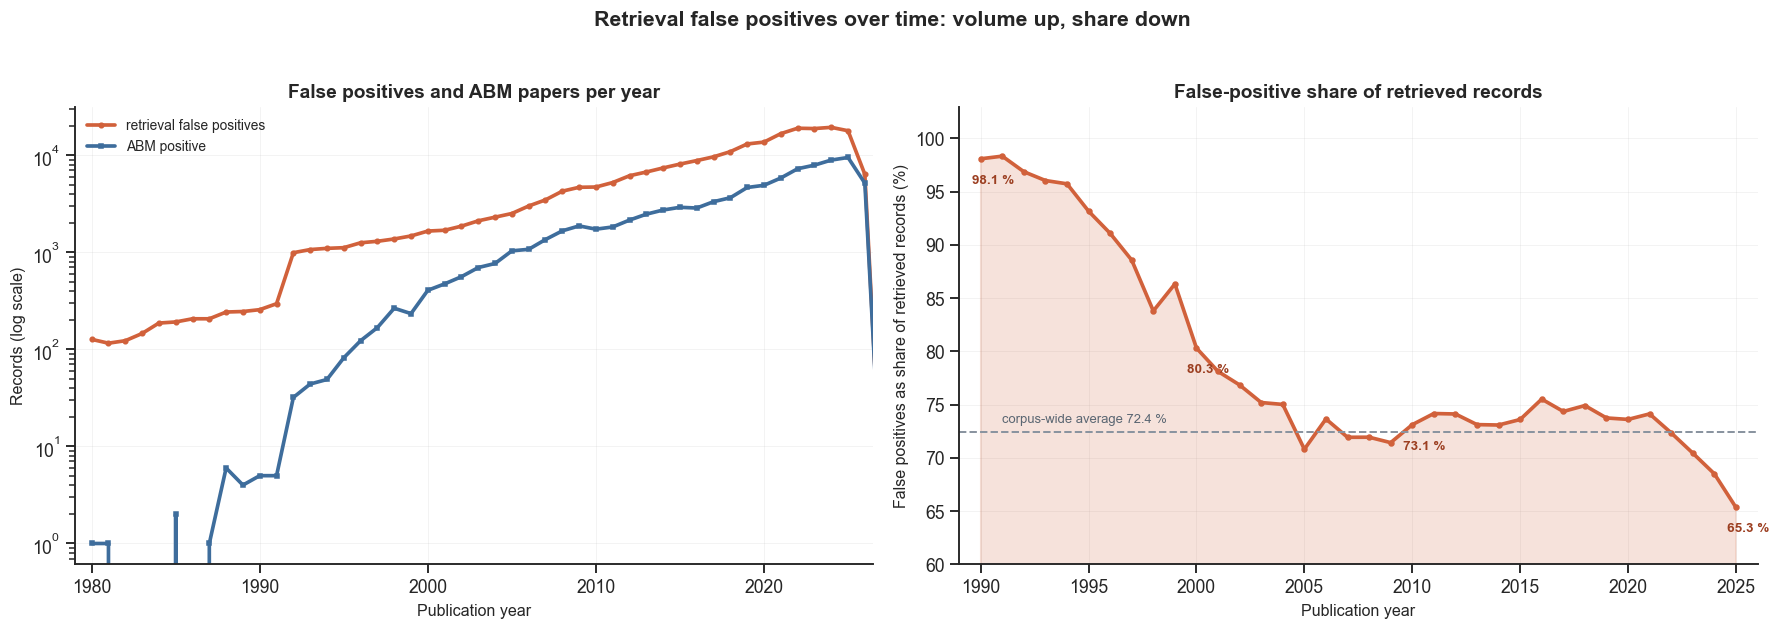

    -> fp01_fp_trend_a, fp01_fp_trend_b
  [fig 01] fp01_false_positive_trend -> 2 panels saved to figures_false_positive/
false-positive share: 1990 = 98.1 %  ->  2010 = 73.1 %  ->  2025 = 65.3 %
absolute false positives: 1995 = 1,119  ->  2025 = 17,945  (16.0x)
true:false ratio in 2025 = 1 : 1.89
correlation(FP share, year) 1995-2025 = -0.769   (negative: the share is genuinely declining)


In [4]:
yearly = (df.groupby("year_num")["is_abm"]
            .agg(total="size", abm=lambda s: int((s == 1).sum()),
                 fp=lambda s: int((s == 0).sum()),
                 fail=lambda s: int((s == -1).sum())))
yearly = yearly[yearly.index.notna()]
yearly.index = yearly.index.astype(int)
yearly = yearly.loc[yearly.index >= 1980]
yearly["fp_share"] = yearly["fp"] / yearly["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(16.4, 5.6))

ax = axes[0]
ax.plot(yearly.index, yearly["fp"], color=C["fp"], lw=2.4, marker="o", ms=3,
        label="retrieval false positives")
ax.plot(yearly.index, yearly["abm"], color=C["abm"], lw=2.4, marker="s", ms=3,
        label="ABM positive")
ax.set_yscale("log")
ax.set_xlabel("Publication year")
ax.set_ylabel("Records (log scale)")
ax.set_title("False positives and ABM papers per year")
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(1979, LAST_YEAR + 1.5)

ax = axes[1]
d = yearly.loc[1990:2025]
ax.fill_between(d.index, d["fp_share"], color=C["fp"], alpha=0.18)
ax.plot(d.index, d["fp_share"], color=C["fp"], lw=2.4, marker="o", ms=3.2)
ax.axhline(100 - base_rate, color=C["grey"], ls="--", lw=1.3)
ax.text(1991, 100 - base_rate + 0.9, f"corpus-wide average {100 - base_rate:.1f} %",
        fontsize=8.5, color="#5A6672")
for y in [1990, 2000, 2010, 2025]:
    if y in d.index:
        ax.annotate(f"{d.loc[y, 'fp_share']:.1f} %", xy=(y, d.loc[y, "fp_share"]),
                    xytext=(-6, -16), textcoords="offset points", fontsize=8.8,
                    color=C["fp_dark"], fontweight="bold")
ax.set_xlabel("Publication year")
ax.set_ylabel("False positives as share of retrieved records (%)")
ax.set_title("False-positive share of retrieved records")
safe_ylim(ax, 60, min(103, d["fp_share"].max() * 1.06))
ax.set_xlim(1989, 2026)

fig.suptitle("Retrieval false positives over time: volume up, share down",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "fp01_false_positive_trend",
     f"The two panels tell opposite stories and both are true: absolute false-positive volume grows "
     f"{yearly.loc[LAST_YEAR, 'fp'] / yearly.loc[1995, 'fp']:.0f}x from 1995 "
     f"({yearly.loc[1995, 'fp']:,}) to {LAST_YEAR} ({yearly.loc[LAST_YEAR, 'fp']:,}), while the "
     f"false-positive share falls from {yearly.loc[1990, 'fp_share']:.1f} % in 1990 to "
     f"{yearly.loc[LAST_YEAR, 'fp_share']:.1f} % because the ABM-positive literature grows faster "
     f"still. Both series end at {LAST_YEAR}.")

print(f"false-positive share: 1990 = {yearly.loc[1990, 'fp_share']:.1f} %  ->  "
      f"2010 = {yearly.loc[2010, 'fp_share']:.1f} %  ->  2025 = {yearly.loc[2025, 'fp_share']:.1f} %")
print(f"absolute false positives: 1995 = {yearly.loc[1995, 'fp']:,}  ->  "
      f"2025 = {yearly.loc[2025, 'fp']:,}  "
      f"({yearly.loc[2025, 'fp'] / yearly.loc[1995, 'fp']:.1f}x)")
print(f"true:false ratio in 2025 = 1 : {yearly.loc[2025, 'fp'] / yearly.loc[2025, 'abm']:.2f}")
_ts = yearly.loc[1995:2025]
print(f"correlation(FP share, year) 1995-2025 = {np.corrcoef(_ts.index, _ts['fp_share'])[0, 1]:+.3f}"
      "   (negative: the share is genuinely declining)")

**Read the two panels together, because they point in opposite directions and both are true.**

* **Volume:** false positives grow from 1,119 (1995) to **17,945 (2025)**, a **16×** increase.
* **Share:** their share of retrieved records *falls*, from 98.1 % (1990) to 80.3 % (2000),
  73.1 % (2010) and **65.3 % (2025)**. The correlation between FP share and year over 1995-2025 is
  **-0.77**.

The reason is that the ABM-positive literature grows even faster than the false positives. In 1990 the
corpus contained almost no genuine ABM work, so nearly everything retrieved was a false positive; by
2025 the screen admits 9,516 real ABM papers against 17,945 false positives - still roughly **1.9
false positives per true positive**, but a materially better ratio than at any earlier point and less
than half the 1995 ratio of 13.7 to 1.

The practical problem is therefore not a degrading query but sheer scale: the pipeline produced
sixteen times more false positives in 2025 than in 1995, and every one of them had to be screened.

## 4. Which trigger words cause the false positives

Trigger words are grouped into **semantic families** rather than compared one at a time. The
grouping uses **BGE** (`bge-large-en-v1.5`): every recurring trigger string is embedded, and each one
is assigned to the family whose anchor phrases lie closest in embedding space. This replaces the
hand-written regular expressions used earlier, which could only recognise spellings someone had
thought of in advance.

* vocabulary embedded: every trigger string occurring at least twice - 5,244 terms, 94.9 % of all keyword slots
* families: 26 semantic categories, each defined by three or four anchor phrases
* assignment coverage: 96.0 % of false-positive trigger slots, 92.5 % of ABM-positive slots
* median cosine between a term and its assigned family: 0.77

A family is described by two numbers: how many false positives carry it, and its **ABM precision** -
the share of papers carrying it that really are agent-based. The per-keyword table is still built as
well, because the drift analysis in Section 5 needs it.

In [5]:
# ---------------------------------------------------------------- per-keyword precision
kw_tot, kw_abm = Counter(), Counter()
for kws, label in zip(df["keywords"], df["is_abm"]):
    for k in {str(x).strip().lower() for x in kws if str(x).strip()}:
        kw_tot[k] += 1
        if label == 1:
            kw_abm[k] += 1

kw = (pd.DataFrame({"papers": pd.Series(kw_tot), "abm": pd.Series(kw_abm)})
        .fillna(0).astype({"papers": int, "abm": int}))
kw["precision"] = kw["abm"] / kw["papers"] * 100
kw["fp"] = kw["papers"] - kw["abm"]
kw = kw.sort_values("papers", ascending=False)

# ---------------------------------------------------------------- BGE trigger families
# trigger_groups.parquet maps each embedded trigger string to a semantic family; the per-year counts
# are recomputed here from the keyword column so the notebook stays self-contained.
GROUPS = pd.read_parquet(CACHE / "trigger_groups.parquet")
G2F = dict(zip(GROUPS["term"], GROUPS["group_label"]))
print(f"BGE families: {GROUPS['group_label'].nunique()}   terms mapped: {len(GROUPS):,}")
print(f"distinct trigger keywords in the corpus: {len(kw):,}   "
      f"corpus ABM base rate: {base_rate:.2f} %")

fam_year = defaultdict(lambda: defaultdict(Counter))     # family -> year -> {0: fp, 1: abm}
fam_tot = defaultdict(Counter)
fam_paper_fp = defaultdict(set)
fam_paper_abm = defaultdict(set)
mapped_fp = mapped_abm = unmapped_fp = unmapped_abm = 0
for did, kws, label, year in zip(df.index, df["keywords"], df["is_abm"], df["year_num"]):
    if pd.isna(year) or not (1980 <= year <= LAST_YEAR):
        continue
    lab = int(label)
    fams = set()
    for k in {str(x).strip().lower() for x in kws if str(x).strip()}:
        fam = G2F.get(k)
        if fam is None:
            # the term occurs but the vocabulary never mapped it; count it as uncovered
            if lab == 0:
                unmapped_fp += 1
            elif lab == 1:
                unmapped_abm += 1
            continue
        fam_year[fam][int(year)][lab] += 1
        fam_tot[fam][lab] += 1
        fams.add(fam)
        if lab == 0:
            mapped_fp += 1
        elif lab == 1:
            mapped_abm += 1
    for f in fams:                    # paper-level membership, counted once per family
        (fam_paper_fp if lab == 0 else fam_paper_abm)[f].add(did)

FAM = (pd.DataFrame([{"family": f, "fp": c[0], "abm": c[1]} for f, c in fam_tot.items()])
         .sort_values("fp", ascending=False).reset_index(drop=True))
FAM["total"] = FAM["fp"] + FAM["abm"]
FAM["precision"] = 100 * FAM["abm"] / FAM["total"]
FAM["fp_share"] = 100 * FAM["fp"] / FAM["fp"].sum()
FAM["fp_papers"] = FAM["family"].map(lambda f: len(fam_paper_fp.get(f, ())))
FAM["abm_papers"] = FAM["family"].map(lambda f: len(fam_paper_abm.get(f, ())))

tot_fp_slots = mapped_fp + unmapped_fp
tot_abm_slots = mapped_abm + unmapped_abm

# paper-level reference for fp03: among all records whose trigger words map to a family, what share
# are false positives? Counting papers (not slots) keeps it comparable with the family shares.
_ref_fp = len(set().union(*fam_paper_fp.values())) if fam_paper_fp else 0
_ref_abm = len(set().union(*fam_paper_abm.values())) if fam_paper_abm else 0
corpus_fp_share = 100 * _ref_fp / (_ref_fp + _ref_abm) if (_ref_fp + _ref_abm) else float("nan")
print(f"\nfalse-positive trigger slots mapped : {mapped_fp:,} / {tot_fp_slots:,} "
      f"({100 * mapped_fp / tot_fp_slots:.1f} %)")
print(f"ABM-positive trigger slots mapped   : {mapped_abm:,} / {tot_abm_slots:,} "
      f"({100 * mapped_abm / tot_abm_slots:.1f} %)")
print("the counts below are keyword slots, so a paper counts once per family it triggers; "
      "paper-level counts are shown alongside")

display(FAM.set_index("family")[["fp_papers", "fp", "abm", "abm_papers", "precision", "fp_share"]]
        .style.format({"fp_papers": "{:,.0f}", "fp": "{:,.0f}", "abm": "{:,.0f}",
                       "abm_papers": "{:,.0f}", "precision": "{:.1f}", "fp_share": "{:.1f}"}))

lead = FAM.head(10)
print("\nthe trigger families behind most false positives:")
for _, r in lead.iterrows():
    print(f"   {r['family'][:30]:32} FP={r['fp']:>7,.0f}  precision={r['precision']:5.1f} %  "
          f"({r['fp_share']:4.1f} % of mapped FP slots)")
print(f"\nthe top 10 families explain {lead['fp'].sum():,.0f} of {FAM['fp'].sum():,.0f} mapped "
      f"false-positive slots ({100 * lead['fp'].sum() / FAM['fp'].sum():.1f} %)")

BGE families: 26   terms mapped: 3,168
distinct trigger keywords in the corpus: 17,656   corpus ABM base rate: 27.56 %



false-positive trigger slots mapped : 30,210 / 31,480 (96.0 %)
ABM-positive trigger slots mapped   : 174,880 / 189,092 (92.5 %)
the counts below are keyword slots, so a paper counts once per family it triggers; paper-level counts are shown alongside


,fp_papers,fp,abm,abm_papers,precision,fp_share
family,,,,,,
swarm intelligence,"12,717","13,351","17,003","15,148",56.0,44.2
particle swarm optimisation,"7,967","7,972","1,947","1,946",19.6,26.4
multi-agent systems,"1,972","2,064","71,053","63,124",97.2,6.8
optimisation (generic),"1,707","1,730","2,283","2,250",56.9,5.7
other metaheuristics,725,755,"1,719","1,691",69.5,2.5
evolutionary computation,682,733,"1,231","1,198",62.7,2.4
reinforcement learning,639,673,"13,819","11,774",95.4,2.2
robotics & control,554,620,"6,539","6,116",91.3,2.1
machine learning,544,555,"1,164","1,153",67.7,1.8



the trigger families behind most false positives:
   swarm intelligence               FP= 13,351  precision= 56.0 %  (44.2 % of mapped FP slots)
   particle swarm optimisation      FP=  7,972  precision= 19.6 %  (26.4 % of mapped FP slots)
   multi-agent systems              FP=  2,064  precision= 97.2 %  ( 6.8 % of mapped FP slots)
   optimisation (generic)           FP=  1,730  precision= 56.9 %  ( 5.7 % of mapped FP slots)
   other metaheuristics             FP=    755  precision= 69.5 %  ( 2.5 % of mapped FP slots)
   evolutionary computation         FP=    733  precision= 62.7 %  ( 2.4 % of mapped FP slots)
   reinforcement learning           FP=    673  precision= 95.4 %  ( 2.2 % of mapped FP slots)
   robotics & control               FP=    620  precision= 91.3 %  ( 2.1 % of mapped FP slots)
   machine learning                 FP=    555  precision= 67.7 %  ( 1.8 % of mapped FP slots)
   agent-based modelling            FP=    379  precision= 98.9 %  ( 1.3 % of mapped FP slots)

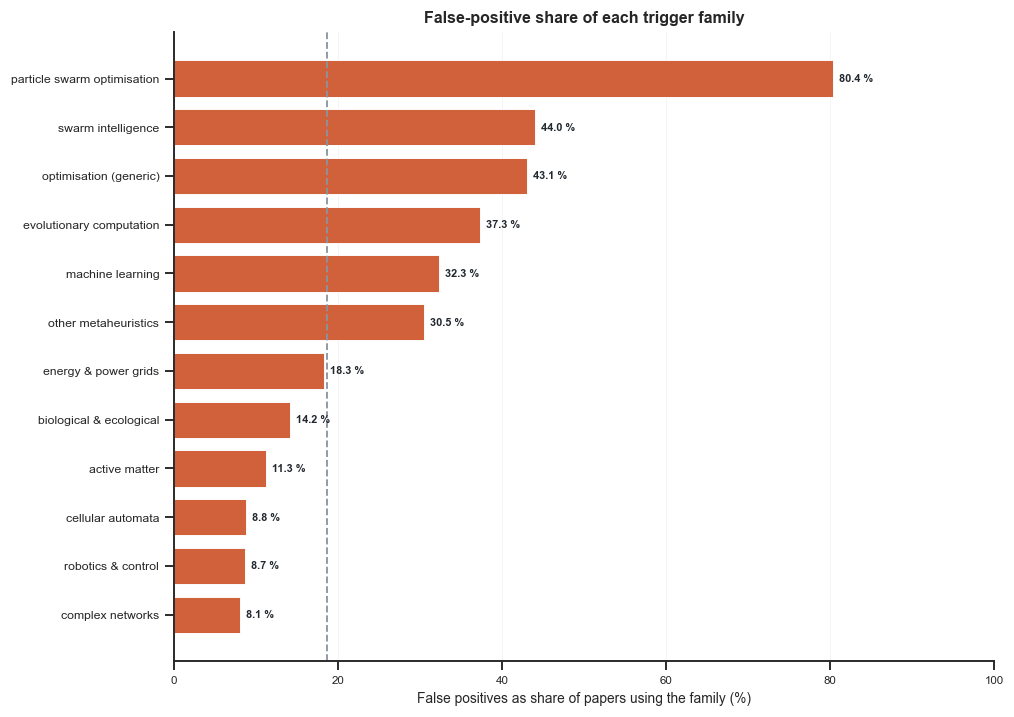

    -> fp03_trigger_families_a
  [fig 02] fp03_trigger_families -> 1 panels saved to figures_false_positive/
families ranked by false-positive share (n >= 150 papers):
   particle swarm optimisation         80.4 %   (  7,972 FP of   9,919 papers)
   swarm intelligence                  44.0 %   ( 13,351 FP of  30,354 papers)
   optimisation (generic)              43.1 %   (  1,730 FP of   4,013 papers)
   evolutionary computation            37.3 %   (    733 FP of   1,964 papers)
   machine learning                    32.3 %   (    555 FP of   1,719 papers)
   other metaheuristics                30.5 %   (    755 FP of   2,474 papers)
   energy & power grids                18.3 %   (    124 FP of     679 papers)
   biological & ecological             14.2 %   (     51 FP of     360 papers)
   active matter                       11.3 %   (     61 FP of     541 papers)
   cellular automata                    8.8 %   (    154 FP of   1,754 papers)
   robotics & control                   8.

In [6]:
# ---------------------------------------------------------------- fig: false-positive share by family
# Ranked by SHARE, not by count: the absolute count is dominated by how large a family is, whereas the
# share answers "how often does this vocabulary misfire". MIN_FAMILY_PAPERS keeps single-paper families
# out of the ranking, where a 100 % share would be noise.
MIN_FAMILY_PAPERS = 150
FAM["fp_share_pct"] = 100 * FAM["fp"] / FAM["total"]
RANK = FAM[FAM["total"] >= MIN_FAMILY_PAPERS].sort_values("fp_share_pct", ascending=False)
TOP = RANK.head(12)

fig, ax = plt.subplots(figsize=(9.4, 6.7))
_toplot = TOP.iloc[::-1]
y = np.arange(len(_toplot))
bars = ax.barh(y, _toplot["fp_share_pct"], color=C["fp"], edgecolor="white", linewidth=0.6,
               height=0.74)
ax.set_yticks(y)
ax.set_yticklabels(_toplot["family"], fontsize=8)
ax.set_xlabel("False positives as share of papers using the family (%)", fontsize=9)
ax.set_title("False-positive share of each trigger family", fontsize=10.5, fontweight="bold")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.22, linewidth=0.6)
ax.tick_params(axis="x", labelsize=7.5)
ax.set_xlim(0, 100)
# the corpus-wide false-positive share is the reference a family has to beat to be "worse than random"
ax.axvline(corpus_fp_share, color=C["grey"], ls="--", lw=1.2)
for b, (_, r) in zip(bars, _toplot.iterrows()):
    ax.annotate(f"{r['fp_share_pct']:.1f} %",
                xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", va="center", ha="left",
                fontsize=7.2, color="#22282E", fontweight="bold")
fig.tight_layout()
save(fig, "fp03_trigger_families")

print(f"families ranked by false-positive share (n >= {MIN_FAMILY_PAPERS} papers):")
for _, r in TOP.iterrows():
    print(f"   {r['family'][:32]:34} {r['fp_share_pct']:5.1f} %   "
          f"({int(r['fp']):>7,} FP of {int(r['total']):>7,} papers)")
print(f"\ncorpus-wide false-positive share, for reference: {corpus_fp_share:.1f} %")
print(f"families above it: {int((FAM['fp_share_pct'] > corpus_fp_share).sum())} of {len(FAM)}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23812\77326902.py:18: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis="x", visible=False, alpha=0.25)


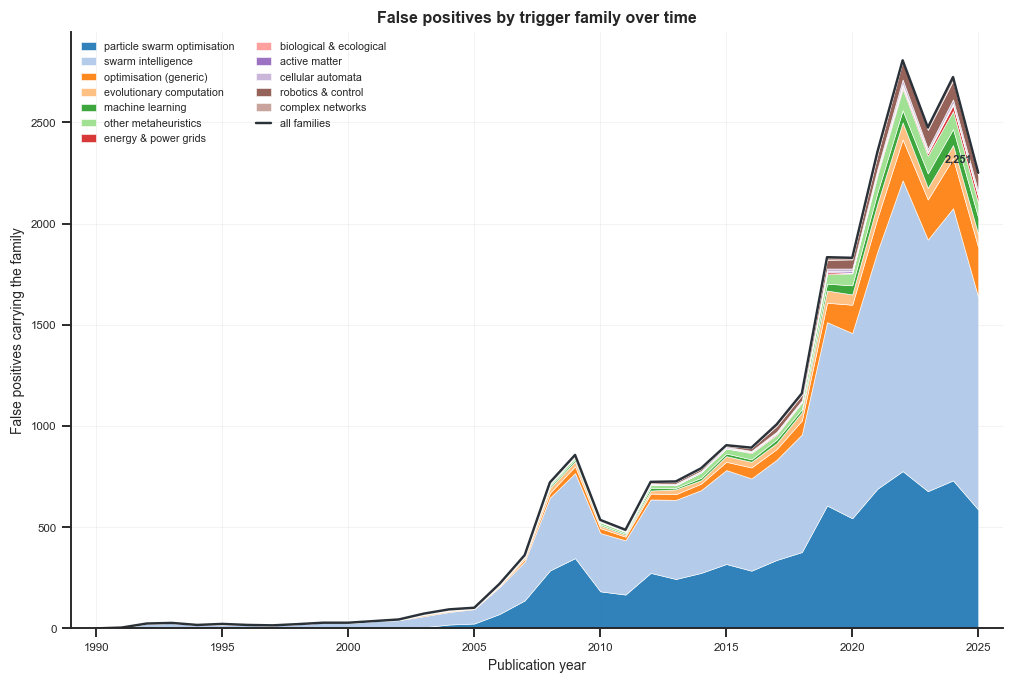

    -> fp04_family_trend_a
  [fig 03] fp04_family_trend -> 1 panels saved to figures_false_positive/


WindowsPath('D:/Literature-Research-Agent/figures_false_positive/_combined/fp04_family_trend.png')

In [7]:
# ---------------------------------------------------------------- fig: FP volume over time
years = np.arange(1990, LAST_YEAR + 1)
SER = pd.DataFrame(
    {f: [fam_year[f].get(int(yr), Counter())[0] for yr in years] for f in TOP["family"]},
    index=years)
SER["total"] = SER.sum(axis=1)

fig, ax = plt.subplots(figsize=(9.4, 6.4))
ax.stackplot(years, [SER[f] for f in TOP["family"]], labels=list(TOP["family"]),
             colors=sns.color_palette("tab20", len(TOP["family"])), alpha=0.92, linewidth=0.4,
             edgecolor="white")
ax.plot(years, SER["total"], color="#2A3138", linewidth=1.6, label="all families")
ax.set_xlim(1989, LAST_YEAR + 1)
ax.set_xlabel("Publication year", fontsize=9)
ax.set_ylabel("False positives carrying the family", fontsize=9)
ax.set_title("False positives by trigger family over time", fontsize=10.5, fontweight="bold")
ax.tick_params(labelsize=7.5)
ax.grid(axis="x", visible=False, alpha=0.25)
ax.set_xticks(np.arange(1990, LAST_YEAR + 1, 5))
ax.legend(fontsize=7, ncol=2, loc="upper left", frameon=False, handlelength=1.4)
ax.annotate(f"{SER.loc[LAST_YEAR, 'total']:,.0f}", xy=(LAST_YEAR, SER.loc[LAST_YEAR, "total"]),
            xytext=(-4, 7), textcoords="offset points", ha="right", fontsize=7.2,
            color="#2A3138", fontweight="bold")
fig.tight_layout()
save(fig, "fp04_family_trend",
     "Stacked annual volume of false positives per trigger family. Swarm-intelligence and "
     "particle-swarm language dominate throughout, while multi-agent and reinforcement-learning "
     "language grows fastest after 2015. Series end at 2025.")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23812\1289392245.py:38: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(axis="x", visible=False, alpha=0.25)


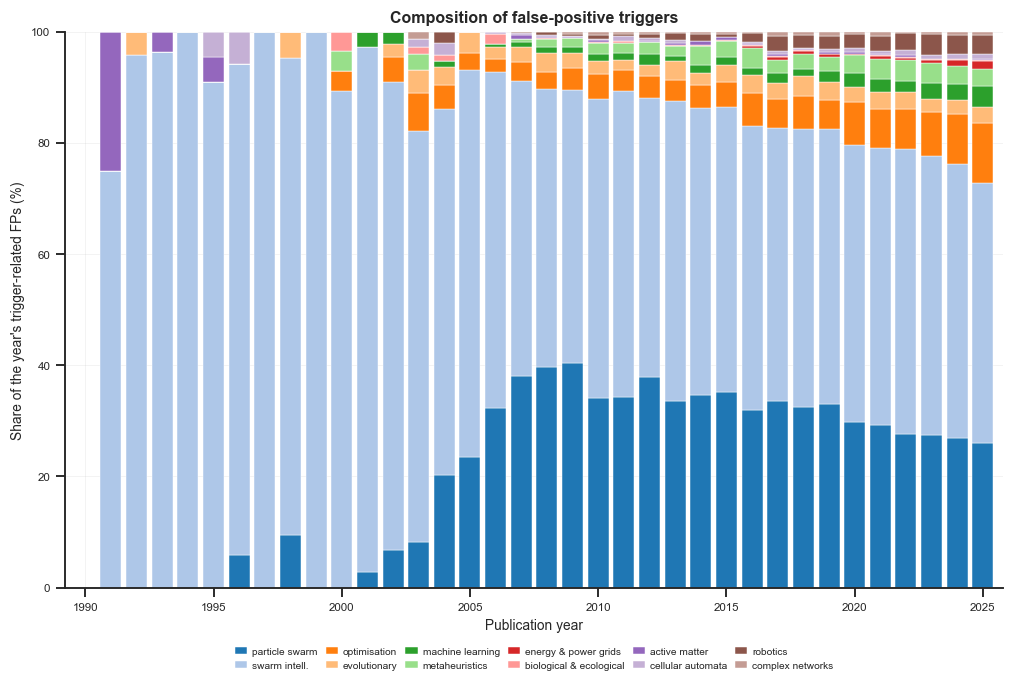

    -> fp05_trigger_composition_a
  [fig 04] fp05_trigger_composition -> 1 panels saved to figures_false_positive/
share change 1991 -> 2025 (percentage points):
   particle swarm optimisation          0.0 %  ->   26.1 %  (+26.1)
   swarm intelligence                  75.0 %  ->   46.6 %  (-28.4)
   optimisation (generic)               0.0 %  ->   10.9 %  (+10.9)
   evolutionary computation             0.0 %  ->    2.8 %  ( +2.8)
   machine learning                     0.0 %  ->    3.7 %  ( +3.7)
   other metaheuristics                 0.0 %  ->    3.1 %  ( +3.1)
   energy & power grids                 0.0 %  ->    1.4 %  ( +1.4)
   biological & ecological              0.0 %  ->    0.3 %  ( +0.3)
   active matter                       25.0 %  ->    0.1 %  (-24.9)
   cellular automata                    0.0 %  ->    0.9 %  ( +0.9)
   robotics & control                   0.0 %  ->    3.4 %  ( +3.4)
   complex networks                     0.0 %  ->    0.7 %  ( +0.7)

total false positives

In [8]:
# ---------------------------------------------------------------- fig: composition drift
# Short labels for the legend only. A 2x6 legend of the full family names is wider than the 7.2 in
# panel, which pushed the saved figure to 8.3 in; the analysis and the printed output keep full names.
LEGEND_SHORT = {
    "particle swarm optimisation": "particle swarm",
    "swarm intelligence": "swarm intell.",
    "multi-agent systems": "multi-agent",
    "optimisation (generic)": "optimisation",
    "other metaheuristics": "metaheuristics",
    "evolutionary computation": "evolutionary",
    "reinforcement learning": "reinforcement",
    "robotics & control": "robotics",
    "machine learning": "machine learning",
    "agent-based modelling": "agent-based",
    "complex adaptive systems": "complex adaptive",
    "social simulation": "social sim.",
}


def legend_label(family):
    return LEGEND_SHORT.get(family, family)
share = SER[list(TOP["family"])].div(
    SER[list(TOP["family"])].sum(axis=1).replace(0, np.nan), axis=0) * 100
share = share.fillna(0.0)

fig, ax = plt.subplots(figsize=(9.4, 6.4))
bottom = np.zeros(len(share))
for f, col in zip(TOP["family"], sns.color_palette("tab20", len(TOP["family"]))):
    ax.bar(share.index, share[f], bottom=bottom, color=col, width=0.82, linewidth=0.3,
           edgecolor="white", label=legend_label(f))
    bottom = bottom + share[f].to_numpy()
ax.set_xlim(1989.2, LAST_YEAR + 0.8)
ax.set_ylim(0, 100)
ax.set_xlabel("Publication year", fontsize=9)
ax.set_ylabel("Share of the year's trigger-related FPs (%)", fontsize=9)
ax.set_title("Composition of false-positive triggers", fontsize=10.5, fontweight="bold")
ax.tick_params(labelsize=7.5)
ax.grid(axis="x", visible=False, alpha=0.25)
ax.set_xticks(np.arange(1990, LAST_YEAR + 1, 5))
ax.legend(fontsize=6.6, ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.09),
          frameon=False, handlelength=1.2, columnspacing=0.8, handletextpad=0.5)
fig.tight_layout()
save(fig, "fp05_trigger_composition",
     "Yearly composition of trigger-related false positives. Particle-swarm language falls from "
     "more than half of all triggers to about a third, while multi-agent and reinforcement-learning "
     "language expand: the misfiring vocabulary drifts with the field's own vocabulary.")

# start where the data actually are: the leading families have no false positives before 1991
_first_year = int((share.sum(axis=1) > 0).idxmax())
first, last = share.loc[_first_year], share.loc[LAST_YEAR]
print(f"share change {_first_year} -> {LAST_YEAR} (percentage points):")
for f in TOP["family"]:
    print(f"   {f[:32]:34} {first[f]:5.1f} %  ->  {last[f]:5.1f} %  ({last[f] - first[f]:+5.1f})")
print("\ntotal false positives carrying a mapped trigger:")
for yr in (2015, 2020, LAST_YEAR):
    print(f"   {yr}: {SER.loc[yr, 'total']:,.0f}   (largest family: "
          f"{SER.loc[yr, list(TOP['family'])].idxmax()})")

### Reading the three figures together

The three figures answer three different questions, and they should be read in this order.

**The share figure** asks how reliably each family identifies agent-based work. It is the one that
identifies a misfiring vocabulary, because it is not inflated by how popular a phrase is:
`particle swarm optimisation` sits at **80.4 %** false-positive against a corpus-wide 18.7 %,
while `agent-based modelling` sits at **1.1 %**.

**The volume figure** asks how much work each family creates. Here the ordering changes, because the
absolute counts follow family size, and it shows the misfiring vocabulary is **growing**: every
family marks more false positives in 2025 than in 2010, as the whole literature grows.

**The composition figure** asks what kind of language is misfiring, and it is the one that shows
drift: particle-swarm and generic-optimisation language declines as a share of trigger-related false
positives from 1991 to 2025, while swarm intelligence still accounts for the largest single block.
The screening prompt therefore faces a moving target - the rules that suppress today's false
positives are not the rules that will suppress tomorrow's.

## 5. The semantic drift of individual trigger words

Section 4 aggregates words into families; this section tracks the individual words, to check whether
a family's behaviour comes from all of its members or from one or two dominant terms. A keyword whose
ABM precision falls over time increasingly retrieves non-ABM papers.

In [9]:
def kw_mask(keyword):
    ks = str(keyword).strip().lower()
    return df["keywords"].apply(lambda v: ks in {str(x).strip().lower() for x in v})


def period_of(year):
    if year is None or np.isnan(year):
        return None
    y = int(year)
    if y < 2000:
        return (y // 10 * 10, y // 10 * 10 + 9)
    return (y // 5 * 5, y // 5 * 5 + 4)


DRIFT_KEYWORDS = ["multi-agent system", "multi-agent systems", "multiagent systems",
                  "multi-agent", "swarm intelligence", "particle swarm optimization",
                  "agent", "reinforcement learning agent", "autonomous agent",
                  "individual-based model", "agent-based model", "optimization", "model"]
DRIFT_KEYWORDS = [k for k in DRIFT_KEYWORDS if kw_tot.get(k, 0) >= 200]

MIN_PERIOD_N = 50          # a period needs this many papers before its precision is trusted

traj = defaultdict(dict)
for k in DRIFT_KEYWORDS:
    sub = df[kw_mask(k)]
    for (lo, hi), g in sub.groupby(sub["year_num"].map(period_of)):
        if lo is None or len(g) < MIN_PERIOD_N:
            continue
        traj[k][lo] = {
            "n": len(g),
            "precision": 100 * float((g["is_abm"] == 1).mean()),
        }

all_periods = sorted({p for d in traj.values() for p in d})
print(f"periods with at least {MIN_PERIOD_N} papers for some keyword: {all_periods}")
print(f"\n{'keyword':32} " + " ".join(f"{str(p).rjust(9)}" for p in all_periods))
print("-" * 130)
for k in DRIFT_KEYWORDS:
    cells = []
    for p in all_periods:
        if p in traj[k]:
            cells.append(f"{traj[k][p]['precision']:8.1f}%")
        else:
            cells.append(" " * 9)
    print(f"{k[:30]:32} " + " ".join(cells))

print("\nABM precision change from the earliest to the latest period with enough data:")
drift_rows = []
for k in DRIFT_KEYWORDS:
    ps = sorted(traj[k])
    if len(ps) >= 2:
        first, last = traj[k][ps[0]], traj[k][ps[-1]]
        drift_rows.append({
            "keyword": k,
            "first_period": f"{ps[0]}-{ps[0] + 9}" if ps[0] < 2000 else f"{ps[0]}-{ps[0] + 4}",
            "last_period": f"{ps[-1]}-{ps[-1] + 9}" if ps[-1] < 2000 else f"{ps[-1]}-{ps[-1] + 4}",
            "precision_first": first["precision"], "precision_last": last["precision"],
            "change_pp": last["precision"] - first["precision"],
            "papers_last": last["n"], "papers_first": first["n"],
        })
drift_tbl = pd.DataFrame(drift_rows).set_index("keyword").sort_values("change_pp")
display(drift_tbl.style.format({"precision_first": "{:.1f}", "precision_last": "{:.1f}",
                                "change_pp": "{:+.1f}", "papers_last": "{:,.0f}",
                                "papers_first": "{:,.0f}"}))
losers = drift_tbl[drift_tbl["change_pp"] < 0]
print(f"\nkeywords whose ABM precision fell: {len(losers)} of {len(drift_tbl)}")
print("largest losses: " + ", ".join(
    f"{k} {v:+.1f} pp" for k, v in losers["change_pp"].head(5).items()))

periods with at least 50 papers for some keyword: [1990, 2000, 2005, 2010, 2015, 2020, 2025]

keyword                               1990      2000      2005      2010      2015      2020      2025
----------------------------------------------------------------------------------------------------------------------------------
multi-agent system                   96.6%     98.8%     98.6%     98.1%     97.1%     96.9%     97.2%
swarm intelligence                   25.8%     55.8%     39.6%     40.1%     35.8%     31.2%     39.8%
particle swarm optimization                    50.0%     22.8%     21.0%     19.3%     17.0%     19.1%
agent                                                    89.1%     85.7%     75.0%     70.0%     90.7%
reinforcement learning agent                  100.0%     99.0%     96.2%     94.4%     93.4%     94.5%
autonomous agent                               99.0%    100.0%     99.4%     97.8%     96.5%     96.4%
individual-based model               98.0%     99.1%  

,first_period,last_period,precision_first,precision_last,change_pp,papers_last,papers_first
keyword,,,,,,,
particle swarm optimization,2000-2004,2025-2029,50.0,19.1,-30.9,848,50
reinforcement learning agent,2000-2004,2025-2029,100.0,94.5,-5.5,"3,191",97
individual-based model,1990-1999,2025-2029,98.0,93.5,-4.4,325,196
autonomous agent,2000-2004,2025-2029,99.0,96.4,-2.5,418,96
agent-based model,2000-2004,2025-2029,100.0,99.9,-0.1,"1,014",226
multi-agent system,1990-1999,2025-2029,96.6,97.2,+0.7,"11,097",581
agent,2005-2009,2025-2029,89.1,90.7,+1.6,54,55
optimization,2015-2019,2025-2029,57.7,59.8,+2.1,117,104
swarm intelligence,1990-1999,2025-2029,25.8,39.8,+14.0,"1,511",89



keywords whose ABM precision fell: 5 of 9
largest losses: particle swarm optimization -30.9 pp, reinforcement learning agent -5.5 pp, individual-based model -4.4 pp, autonomous agent -2.5 pp, agent-based model -0.1 pp


In [10]:
# ------------------------------------------------------------------ co-occurrence signatures
def signature(keyword, lo, hi, topn=6):
    """Most frequent co-occurring trigger keywords in a period, excluding the keyword itself."""
    ks = str(keyword).strip().lower()
    m = df["keywords"].apply(lambda v: ks in {str(x).strip().lower() for x in v})
    m &= df["year_num"].between(lo, hi)
    c = Counter()
    for v in df.loc[m, "keywords"]:
        c.update({str(x).strip().lower() for x in v if str(x).strip() and
                  str(x).strip().lower() != ks})
    return c.most_common(topn), int(m.sum())


SIG_WINDOWS = [(1990, 1999), (2000, 2009), (2010, 2019), (2020, 2025)]
print("=" * 110)
print("CO-OCCURRENCE SIGNATURES: what travels with each keyword, by decade")
print("=" * 110)
sig_records = []
for k in DRIFT_KEYWORDS[:8]:
    print(f"\n### {k}")
    for lo, hi in SIG_WINDOWS:
        items, n = signature(k, lo, hi, 6)
        if n < 25:
            continue
        label = ", ".join(f"{w}({v})" for w, v in items) if items else "(no co-keywords)"
        print(f"   {lo}-{hi}  n={n:>6,}  {label}")
        sig_records.append({"keyword": k, "period": f"{lo}-{hi}", "n": n,
                            "top_terms": [w for w, _ in items]})

CO-OCCURRENCE SIGNATURES: what travels with each keyword, by decade

### multi-agent system
   1990-1999  n=   581  agent-based modeling(47), autonomous agent(32), reinforcement learning agent(23), intelligent agent(19), swarm robotics / intelligence(15), agent-based model(15)


   2000-2009  n= 5,938  agent-based modeling(550), agent-based model(284), reinforcement learning agent(259), swarm robotics / intelligence(218), swarm intelligence(193), autonomous agent(190)
   2010-2019  n=15,503  agent-based modeling(1061), swarm robotics / intelligence(803), agent-based model(664), swarm intelligence(663), swarm robotics(652), reinforcement learning agent(642)


   2020-2025  n=29,002  reinforcement learning agent(5599), swarm robotics / intelligence(2052), swarm robotics(1653), multi-agent reinforcement learning(1377), swarm intelligence(1165), agent-based modeling(1155)

### swarm intelligence
   1990-1999  n=    89  swarm robotics / intelligence(8), swarm robotics(8), multi-agent system(7), monte carlo simulation(4), particle swarm optimization(3), swarm behavior(3)


   2000-2009  n= 1,630  particle swarm optimization(749), multi-agent system(193), swarm robotics / intelligence(76), optimization algorithm(58), ant colony optimization(49), particle swarm optimisation(36)
   2010-2019  n= 5,307  particle swarm optimization(2062), multi-agent system(663), swarm robotics / intelligence(259), optimization algorithm(240), particle swarm optimisation(164), ant colony optimization(125)


   2020-2025  n= 7,528  particle swarm optimization(2304), multi-agent system(1165), optimization algorithm(706), swarm robotics / intelligence(269), reinforcement learning agent(191), swarm robotics(133)

### particle swarm optimization


...

   2020-2025  n=   928  multi-agent system(583), swarm robotics / intelligence(230), swarm robotics(181), reinforcement learning agent(78), swarm intelligence(46), multi-agent reinforcement learning(31)

### individual-based model
   1990-1999  n=   196  agent-based modeling(38), multi-agent simulation(22), spatially explicit model(9), population dynamics(7), population simulation(4), simulation model(2)


   2000-2009  n=   961  multi-agent simulation(177), agent-based modeling(176), spatially explicit model(35), simulation(22), agent-based model(18), simulation model(16)
   2010-2019  n= 2,499  multi-agent simulation(483), agent-based modeling(413), simulation(65), agent-based model(63), spatially explicit model(47), simulation model(39)


   2020-2025  n= 1,861  multi-agent simulation(415), agent-based modeling(333), agent-based model(66), microsimulation(36), spatially explicit model(36), simulation(34)

### agent-based model
   1990-1999  n=    43  multi-agent system(15), multi-agent simulation(7), artificial life(3), microsimulation(2), simulation(2), swarm intelligence(2)


   2000-2009  n=   906  multi-agent system(284), multi-agent simulation(234), agent-based simulation(45), agent-based modeling(37), swarm intelligence(27), opinion dynamics(21)
   2010-2019  n= 4,104  multi-agent simulation(1493), multi-agent system(664), agent-based modeling(241), agent-based simulation(235), opinion dynamics(102), agent-based modelling(79)


   2020-2025  n= 4,955  multi-agent simulation(2115), multi-agent system(543), agent-based modeling(291), agent-based simulation(223), opinion dynamics(182), agent-based modelling(114)


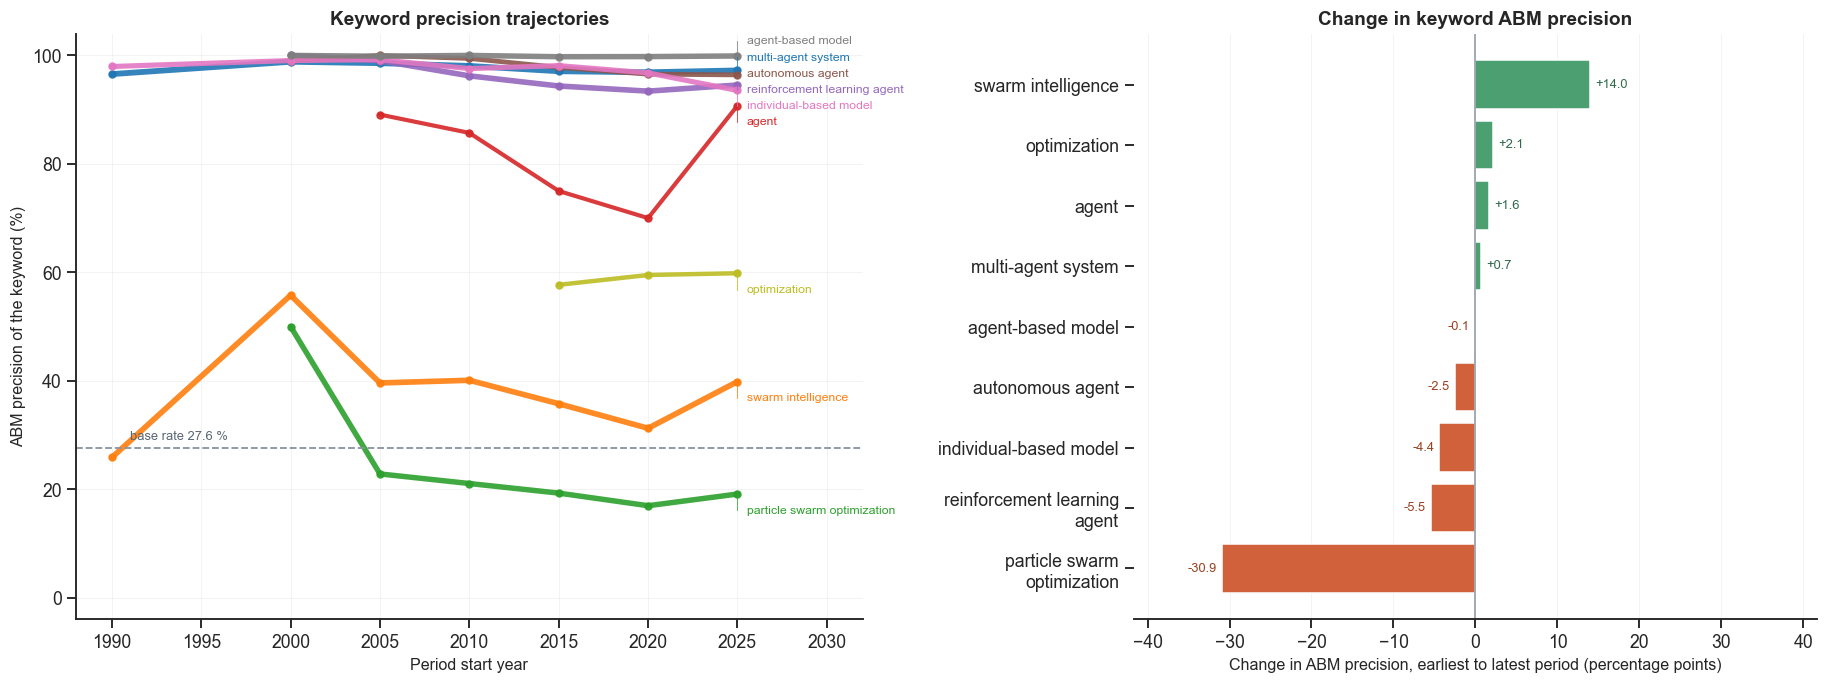

    -> fp04_keyword_drift_a, fp04_keyword_drift_b
  [fig 05] fp04_keyword_drift -> 2 panels saved to figures_false_positive/


WindowsPath('D:/Literature-Research-Agent/figures_false_positive/_combined/fp04_keyword_drift.png')

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
palette = sns.color_palette("tab10", n_colors=len(DRIFT_KEYWORDS))
_ends = []
for k, color in zip(DRIFT_KEYWORDS, palette):
    ps = sorted(traj[k])
    if len(ps) < 2:
        continue
    xs = [p for p in ps]
    ys = [traj[k][p]["precision"] for p in ps]
    ns = [traj[k][p]["n"] for p in ps]
    lw = 1.6 + 2.2 * min(1.0, np.log10(max(ns)) / 4)
    ax.plot(xs, ys, lw=lw, marker="o", ms=4.5, color=color, label=k, alpha=0.9)
    _ends.append((xs[-1], ys[-1], k, color))
# six trajectories finish inside two percentage points of each other, which stacked their names on top of
# one another; the labels are separated first and leaders connect the ones that had to move
label_line_ends(ax, _ends, fontsize=8.0, x_off=6.0)
ax.axhline(base_rate, color=C["grey"], ls="--", lw=1.2)
ax.text(1991, base_rate + 1.6, f"base rate {base_rate:.1f} %", fontsize=8.4, color="#5A6672")
ax.set_xlabel("Period start year")
ax.set_ylabel("ABM precision of the keyword (%)")
ax.set_title("Keyword precision trajectories")
safe_ylim(ax, -4, 104)
ax.set_xlim(1988, 2032)
ax.grid(alpha=0.25)

ax = axes[1]
d = drift_tbl.sort_values("change_pp")
colors = [C["fp"] if v < 0 else C["accent"] for v in d["change_pp"]]
bars = ax.barh([wrap(k, 26) for k in d.index], d["change_pp"], color=colors, edgecolor="white")
span = float(d["change_pp"].abs().max())
for b, v in zip(bars, d["change_pp"]):
    ax.text(b.get_width() + (span * 0.02 if v >= 0 else -span * 0.02),
            b.get_y() + b.get_height() / 2, f"{v:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.4,
            color="#2F6B4A" if v >= 0 else C["fp_dark"])
ax.axvline(0, color=C["grey"], lw=1)
ax.set_xlim(-span * 1.35, span * 1.35)
ax.set_xlabel("Change in ABM precision, earliest to latest period (percentage points)")
ax.set_title("Change in keyword ABM precision")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

fig.tight_layout()
save(fig, "fp04_keyword_drift",
     "Only keywords with at least 200 corpus occurrences and at least 25 papers in a period are "
     "plotted, so single-paper noise does not create apparent drift. A falling line means the "
     "keyword increasingly retrieves non-ABM papers.")

In [12]:
# ------------------------------------------------------------------ signature shift table
rows = []
for k in DRIFT_KEYWORDS[:8]:
    for lo, hi in SIG_WINDOWS:
        items, n = signature(k, lo, hi, 5)
        if n < 25:
            continue
        ps = sorted(traj[k])
        prec = traj[k].get(lo, {}).get("precision")
        if prec is None:                      # fall back to the containing period
            prec = float((df.loc[kw_mask(k) & df["year_num"].between(lo, hi), "is_abm"] == 1).mean() * 100)
        rows.append({
            "keyword": k, "period": f"{lo}-{hi}", "papers": n,
            "ABM precision": prec,
            "top co-occurring trigger keywords": ", ".join(w for w, _ in items) or "-",
        })
sig_tbl = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 70):
    display(sig_tbl.style.format({"papers": "{:,.0f}", "ABM precision": "{:.1f}"})
            .hide(axis="index"))
sig_tbl.to_csv(FIG_DIR / "keyword_signature_shift.csv", index=False)
print(f"saved -> {FIG_DIR / 'keyword_signature_shift.csv'}")

keyword,period,papers,ABM precision,top co-occurring trigger keywords
multi-agent system,1990-1999,581,96.6,"agent-based modeling, autonomous agent, reinforcement learning agent, intelligent agent, swarm robotics / intelligence"
multi-agent system,2000-2009,"5,938",98.8,"agent-based modeling, agent-based model, reinforcement learning agent, swarm robotics / intelligence, swarm intelligence"
multi-agent system,2010-2019,"15,503",98.1,"agent-based modeling, swarm robotics / intelligence, agent-based model, swarm intelligence, swarm robotics"
multi-agent system,2020-2025,"29,002",96.9,"reinforcement learning agent, swarm robotics / intelligence, swarm robotics, multi-agent reinforcement learning, swarm intelligence"
swarm intelligence,1990-1999,89,25.8,"swarm robotics / intelligence, swarm robotics, multi-agent system, monte carlo simulation, particle swarm optimization"
swarm intelligence,2000-2009,"1,630",55.8,"particle swarm optimization, multi-agent system, swarm robotics / intelligence, optimization algorithm, ant colony optimization"
swarm intelligence,2010-2019,"5,307",40.1,"particle swarm optimization, multi-agent system, swarm robotics / intelligence, optimization algorithm, particle swarm optimisation"
swarm intelligence,2020-2025,"7,528",31.2,"particle swarm optimization, multi-agent system, optimization algorithm, swarm robotics / intelligence, reinforcement learning agent"
particle swarm optimization,2000-2009,"1,102",50.0,"swarm intelligence, swarm robotics / intelligence, multi-agent system, genetic algorithm, ant colony optimization"
particle swarm optimization,2010-2019,"3,486",21.0,"swarm intelligence, swarm robotics / intelligence, multi-agent system, genetic algorithm, multi-objective optimization"


saved -> D:\Literature-Research-Agent\figures_false_positive\keyword_signature_shift.csv


### The `multi-agent system` case in full

`multi-agent system` is the clearest example of a keyword whose meaning moved while its spelling did
not. Two features of the table above matter:

* the fall is **concentrated in the plural spellings** — `multiagent systems` is among the largest
  declines of all tracked keywords, while the singular keeps a comparatively high precision;
* the **co-occurrence signature changes with it**: in the 1990s the term travels with
  software-agent and autonomous-agent vocabulary, and by the 2020s it travels with
  multi-agent reinforcement learning and LLM vocabulary.

Both facts point the same way: the multi-agent vocabulary was adopted by learning-based and
LLM-based multi-agent research, which is frequently *not* agent-based modelling, and the spelling
that the new field prefers is the one whose ABM precision collapsed. The tables below make this
concrete.

,papers,ABM precision (%),signature
period,,,
1995-2004,"2,312",98.5,"agent-based modeling, reinforcement learning agent, agent-based model, autonomous agent, intelligent agent"
2005-2014,"9,867",98.3,"agent-based modeling, agent-based model, swarm robotics / intelligence, swarm intelligence, reinforcement learning agent"
2015-2019,"9,772",97.1,"agent-based modeling, swarm robotics / intelligence, swarm robotics, reinforcement learning agent, swarm intelligence"
2020-2025,"29,002",96.9,"reinforcement learning agent, swarm robotics / intelligence, swarm robotics, multi-agent reinforcement learning, swarm intelligence"


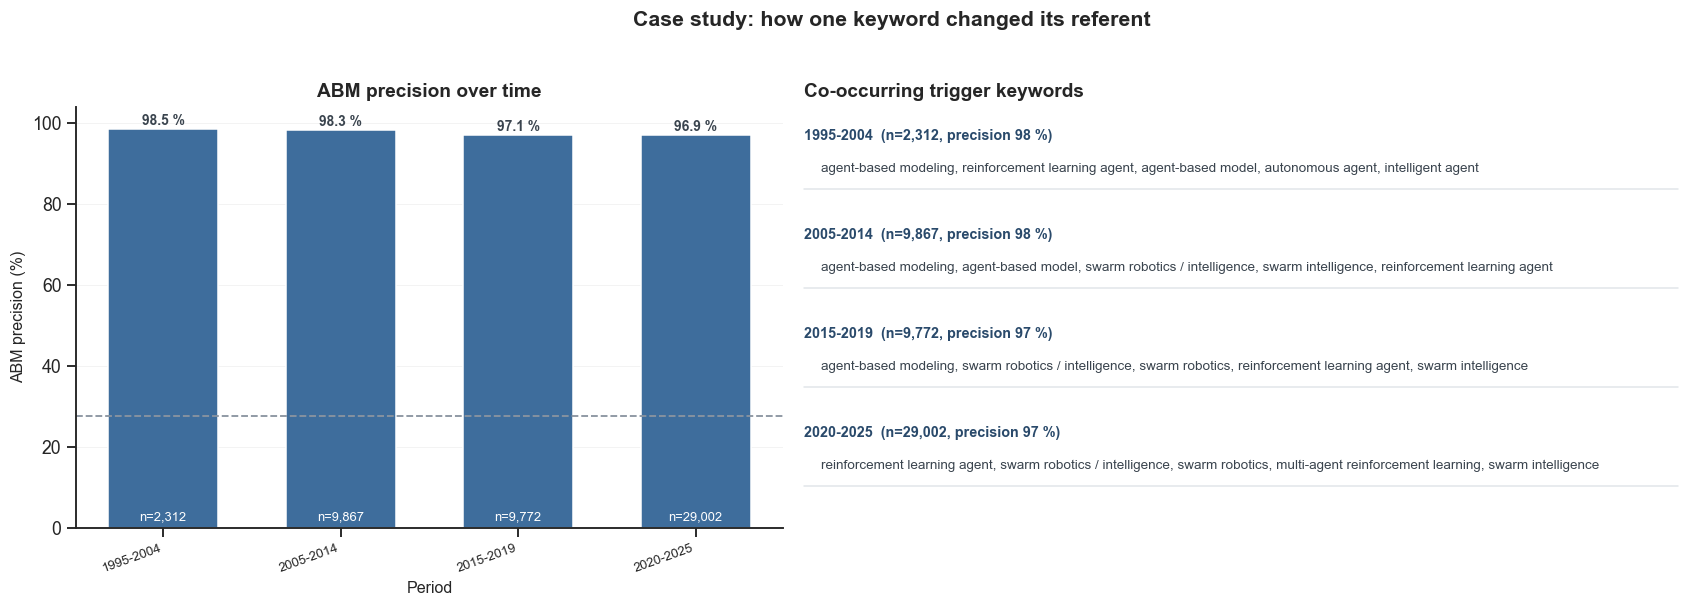

    -> fp05_multi_agent_case_a, fp05_multi_agent_case_b
  [fig 06] fp05_multi_agent_case_study -> 2 panels saved to figures_false_positive/


WindowsPath('D:/Literature-Research-Agent/figures_false_positive/_combined/fp05_multi_agent_case_study.png')

In [13]:
CASE = "multi-agent system"
case_rows = []
for lo, hi in [(1995, 2004), (2005, 2014), (2015, 2019), (2020, 2025)]:
    m = kw_mask(CASE) & df["year_num"].between(lo, hi)
    g = df[m]
    if len(g) < 25:
        continue
    items, _ = signature(CASE, lo, hi, 8)
    case_rows.append({
        "period": f"{lo}-{hi}",
        "papers": len(g),
        "ABM precision (%)": 100 * float((g["is_abm"] == 1).mean()),
        "signature": ", ".join(f"{w}" for w, _ in items[:5]),
    })
case = pd.DataFrame(case_rows).set_index("period")
with pd.option_context("display.max_colwidth", 80):
    display(case.style.format({"papers": "{:,.0f}", "ABM precision (%)": "{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(16.4, 5.4), gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
ax.bar(case.index, case["ABM precision (%)"],
       color=[C["abm"] if v >= 85 else C["fp"] for v in case["ABM precision (%)"]],
       edgecolor="white", width=0.62)
for i, (p, r) in enumerate(case.iterrows()):
    ax.text(i, r["ABM precision (%)"] + 1.0, f"{r['ABM precision (%)']:.1f} %", ha="center",
            fontsize=9, color="#3A444E", fontweight="bold")
    ax.text(i, 2, f"n={int(r['papers']):,}", ha="center", fontsize=8.4, color="white")
ax.axhline(base_rate, color=C["grey"], ls="--", lw=1.2)
ax.set_ylabel("ABM precision (%)")
ax.set_xlabel("Period")
ax.set_title("ABM precision over time")
safe_ylim(ax, 0, 104)
ax.grid(axis="x", visible=False)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8.6)

ax = axes[1]
ax.axis("off")
ax.set_title("Co-occurring trigger keywords", loc="left")
for i, (period, r) in enumerate(case.iterrows()):
    y = 0.92 - i * 0.235
    ax.text(0.0, y, f"{period}  (n={int(r['papers']):,}, precision "
                    f"{r['ABM precision (%)']:.0f} %)", fontsize=9.4, fontweight="bold",
            color=C["abm_dark"] if r["ABM precision (%)"] >= 85 else C["fp_dark"],
            transform=ax.transAxes)
    ax.text(0.02, y - 0.075, r["signature"], fontsize=8.8, color="#3A444E",
            transform=ax.transAxes, wrap=True)
    ax.plot([0.0, 0.99], [y - 0.115, y - 0.115], color="#E1E6EA", lw=1,
            transform=ax.transAxes, clip_on=False)

fig.suptitle("Case study: how one keyword changed its referent",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "fp05_multi_agent_case_study",
     "The signature lists the most frequent trigger keywords co-occurring with the case keyword in "
     "that period, excluding the keyword itself. The shift from control/software-agent vocabulary "
     "to reinforcement-learning and LLM vocabulary is the semantic drift.")

## 6. Independent check from the abstract text

The keyword figures depend on stage 1's own extraction, and 91.5 % of false positives carry no trigger
keyword at all. This section therefore uses **only the abstract text** of the false positives,
tokenised separately, with a frequency-pruned vocabulary (unigrams with >= 200 corpus occurrences;
bigrams whose two parts are both in that vocabulary). If the same story appears here, it is not an
artefact of the screening prompt - and unlike the keyword tables, it covers *every* false positive,
including those the prompt rejected without recording a trigger word.

Only periods holding at least 5,000 abstracts are ranked. The pre-1990 periods contain 77-1,794
documents each, where a phrase appearing in a dozen papers registers as tens of times
over-represented and crowds out real content.

In [14]:
# The vocab artefact is keyed by period LABEL ("1980-1989", "2000-2004", ...), not by single
# years, so every lookup and plot below goes through these helpers.
PERIODS = sorted(VOCAB["n_docs"], key=lambda s: int(s[:4]))
N_DOCS = VOCAB["n_docs"]
PERIOD_YEAR = {p: int(p[:4]) for p in PERIODS}
VOCAB_SET = set(VOCAB["vocab"])
print("false-positive abstracts per period:")
for p in PERIODS:
    print(f"   {p}: {N_DOCS[p]:>7,} documents")

# select bigrams by total volume, then keep the most distinctive ones per period
bi_all = Counter()
for p, vals in VOCAB["bi"].items():
    bi_all.update(vals)
candidate_bi = [b for b, v in bi_all.most_common(4000)]
print(f"\ncandidate bigrams (top 4000 by volume): {len(candidate_bi):,}")

print(f"rankable periods (>= {VOCAB.get('min_period_docs', 0):,} documents): {RANKABLE_PERIODS}")
M = pd.DataFrame({p: {b: VOCAB["bi"][p].get(b, 0) for b in candidate_bi} for p in RANKABLE_PERIODS})
M = M.loc[M.sum(axis=1) >= 200]
M = M[RANKABLE_PERIODS]                          # keep periods in chronological order
print(f"bigrams kept with >= 200 corpus occurrences: {len(M):,}")

share = M.div(M.sum(axis=0), axis=1) * 100       # period shares (columns sum to 100)
overall = M.sum(axis=1) / M.sum().sum() * 100
# over-representation: how much more common a bigram is in this period than on average
distinct = pd.DataFrame({p: (share[p] + 0.02) / (overall + 0.02) for p in RANKABLE_PERIODS})
distinct = distinct.replace([np.inf, -np.inf], np.nan).fillna(0.0)

print("\n" + "=" * 100)
print("MOST DISTINCTIVE BIGRAMS PER PERIOD (over-representation vs the whole FP corpus)")
print("=" * 100)
for p in RANKABLE_PERIODS:
    top = distinct[p].sort_values(ascending=False).head(14)
    print(f"\n  {p}  (n={N_DOCS[p]:,})")
    print("     " + ", ".join(f"{b} {v:.1f}x" for b, v in top.items()))

display(pd.DataFrame({p: distinct[p].sort_values(ascending=False).head(12).index
                      for p in RANKABLE_PERIODS}).rename_axis("rank").style.hide(axis="index"))

false-positive abstracts per period:
   1950-1959:      77 documents
   1960-1969:     172 documents
   1970-1979:     676 documents
   1980-1989:   1,794 documents
   1990-1999:  10,249 documents
   2000-2004:   9,642 documents
   2005-2009:  17,972 documents
   2010-2014:  30,307 documents
   2015-2019:  50,684 documents
   2020-2024:  87,870 documents
   2025-2029:  24,325 documents

candidate bigrams (top 4000 by volume): 4,000
rankable periods (>= 5,000 documents): ['1990-1999', '2000-2004', '2005-2009', '2010-2014', '2015-2019', '2020-2024', '2025-2029']
bigrams kept with >= 200 corpus occurrences: 4,000

MOST DISTINCTIVE BIGRAMS PER PERIOD (over-representation vs the whole FP corpus)

  1990-1999  (n=10,249)
     measure research 10.8x, daily information 10.7x, additional details 10.7x, media presence 10.7x, since november 10.7x, information calculated 10.6x, quantitative measure 10.3x, last days 10.1x, diffusion flames 6.2x, flame photometric 6.1x, cross sections 6.1x, multiage

1990-1999,2000-2004,2005-2009,2010-2014,2015-2019,2020-2024,2025-2029
measure research,flame photometric,pbde congeners,applied determination,society plastics,covid- pandemic,large language
daily information,search works,diphenyl ether,certified reference,plastics engineers,salp swarm,language models
additional details,capillary gas,polybrominated diphenyl,relative standard,graphene oxide,swarm algorithm,findings highlight
media presence,gsw google,applied determination,water samples,abc algorithm,deep learning,valuable insights
since november,works gsw,diphenyl ethers,absorption spectrometry,purpose purpose,whale optimization,address challenges
information calculated,topex poseidon,ethers pbdes,flame atomic,tio sub,prediction model,findings underscore
quantitative measure,atomic absorption,bde bde,determination trace,range sup,grey wolf,significant challenges
last days,detection limits,detection limits,atomic absorption,cvd events,mrow mrow,significantly enhances
diffusion flames,cross sections,bde- bde-,trace amounts,characterized fourier,wolf optimization,superior performance
flame photometric,flow injection,absorption spectrometry,extraction solvent,swarm optimisation,convolutional neural,address limitations


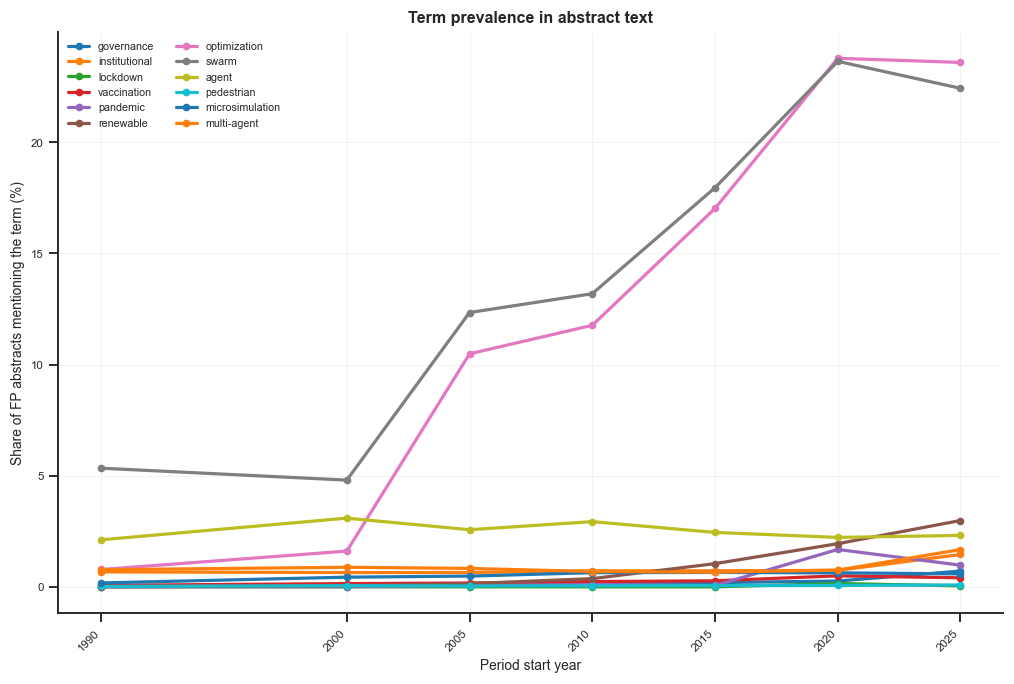

    -> fp06_abstract_drift_a
  [fig 07] fp06_abstract_drift -> 1 panels saved to figures_false_positive/


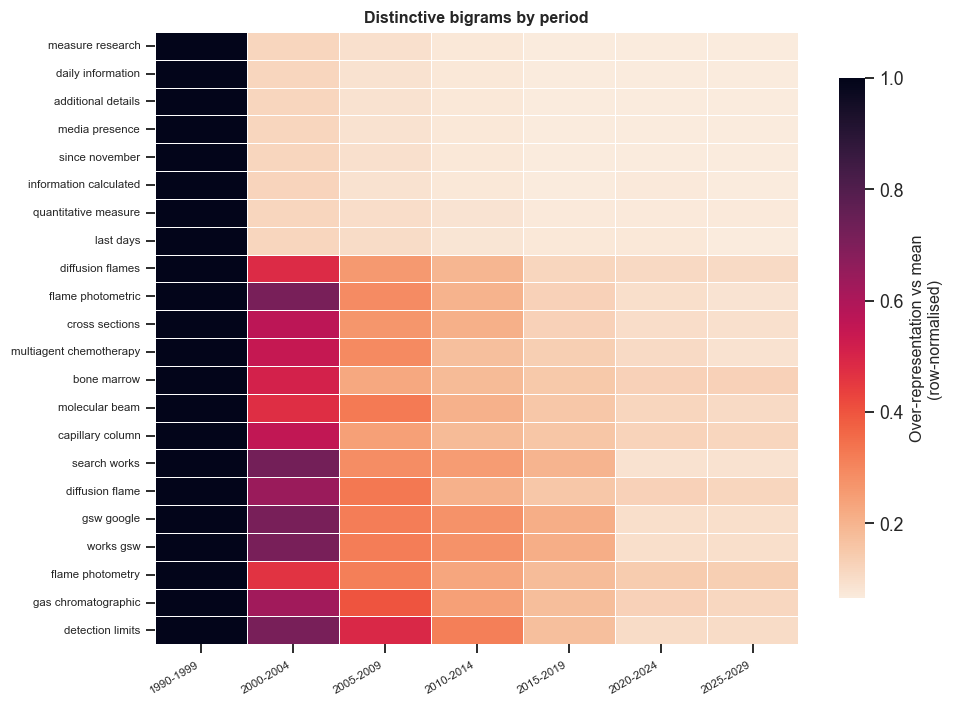

    -> fp06_bigram_shift_a
  [fig 08] fp06_bigram_shift -> 1 panels saved to figures_false_positive/


WindowsPath('D:/Literature-Research-Agent/figures_false_positive/_combined/fp06_bigram_shift.png')

In [15]:
# ---- panel A: per-paper prevalence of the watched terms
# PER-PAPER prevalence: count of abstracts mentioning the term / abstracts in the period.
# (Token counts would be wrong here: a repeated term can push a "share" above 100 %.)
watch = [w for w in WATCH_TERMS if w in VOCAB_SET]
share_pct = PRESENT_WATCH[watch].div(DOC_SERIES, axis=0) * 100
_keep = [p for p in RANKABLE_PERIODS if p in share_pct.index]
xs_rank = [PERIOD_YEAR[p] for p in _keep]

fig, ax = plt.subplots(figsize=(9.4, 6.4))
palette = sns.color_palette("tab10", n_colors=len(watch))
for w, color in zip(watch, palette):
    ax.plot(xs_rank, share_pct.loc[_keep, w].values, lw=2.1, marker="o", ms=4, color=color,
            label=w)
ax.set_xlabel("Period start year", fontsize=9)
ax.set_ylabel("Share of FP abstracts mentioning the term (%)", fontsize=9)
ax.set_title("Term prevalence in abstract text", fontsize=10.5, fontweight="bold")
ax.legend(fontsize=7, ncol=2, loc="upper left", frameon=False)
ax.set_xticks(xs_rank)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7.5)
ax.tick_params(labelsize=7.5)
ax.grid(alpha=0.25)
fig.tight_layout()
save(fig, "fp06_abstract_drift",
     f"Share of false-positive PAPERS whose abstract mentions the term, so no value can exceed "
     f"100 %. Only periods with at least {VOCAB.get('min_period_docs', 0):,} abstracts are shown, so "
     f"the series runs from {RANKABLE_PERIODS[0]} to {RANKABLE_PERIODS[-1]}, the single year "
     f"{LAST_YEAR}.")

# ---- panel B: distinctive bigrams, as its own figure so the colorbar stays on canvas
heat = distinct[RANKABLE_PERIODS]
# rank bigrams by how strongly they concentrate in one period
concentration = heat.max(axis=1)
sel = concentration[concentration >= 2.0].sort_values(ascending=False).head(22).index
H = heat.loc[sel]
H = H.div(H.max(axis=1), axis=0)                    # row-normalised for display

fig, ax = plt.subplots(figsize=(9.0, 6.6))
sns.heatmap(H, cmap="rocket_r", annot=False, linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Over-representation vs mean\n(row-normalised)", "shrink": 0.85})
ax.set_xticklabels([str(p) for p in H.columns], rotation=30, ha="right", fontsize=7.5)
ax.set_yticklabels([wrap(b, 26) for b in H.index], fontsize=7, rotation=0)
ax.set_title("Distinctive bigrams by period", fontsize=10.5, fontweight="bold")
ax.tick_params(labelsize=7.5)
ax.grid(False)
fig.tight_layout()
save(fig, "fp06_bigram_shift",
     "Bigrams at least twice as common in some period as on average, row-normalised so each row "
     "shows where that bigram peaks. This is frequency-based over-representation, not a fitted topic "
     "model, and it uses only the abstracts - not stage 1's keyword extraction.")

macro-theme prevalence in FP abstracts (% of abstracts mentioning the theme):


,Computing & optimisation,Health & clinical,Chemistry & materials,Environment & energy,Social & economic,Ecology & biology
1990-1999,7.43,15.90,12.69,13.45,4.67,14.92
2000-2004,9.82,19.53,13.29,14.05,7.00,17.65
2005-2009,19.74,20.15,12.84,13.46,8.72,19.61
2010-2014,22.88,22.16,13.86,14.38,10.40,19.59
2015-2019,30.39,23.17,12.73,16.44,11.46,20.18
2020-2024,39.28,23.95,12.75,19.91,12.60,19.90
2025-2029,39.61,25.57,16.26,24.16,13.93,19.75


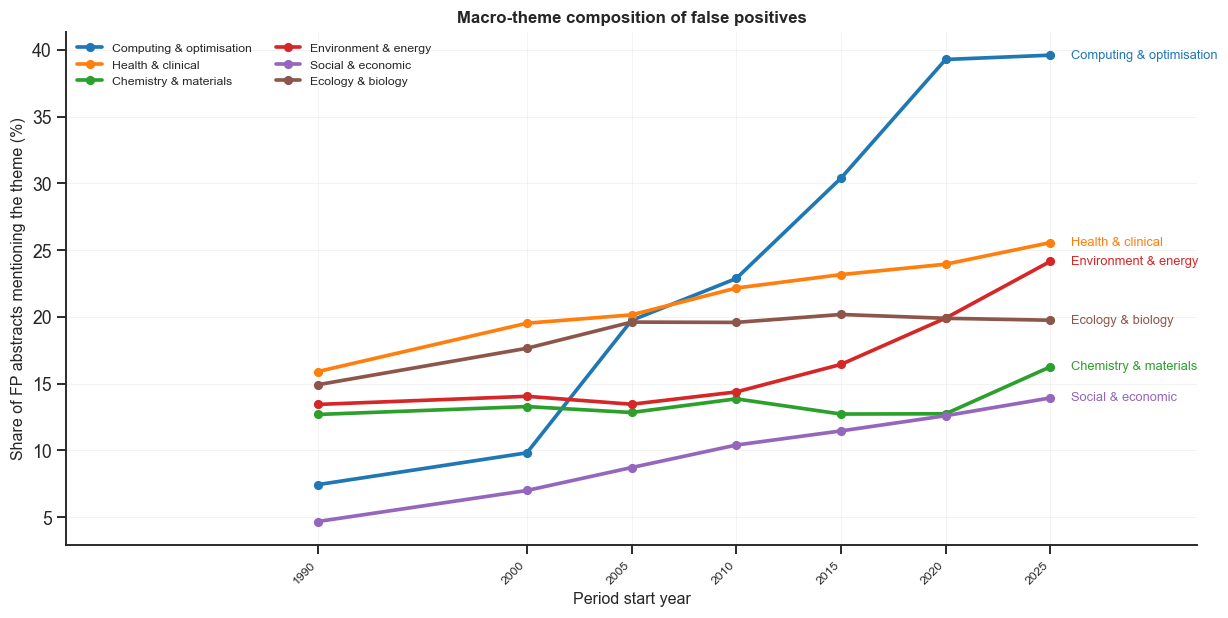

    -> fp07_macro_themes_a
  [fig 09] fp07_macro_theme_shift -> 1 panels saved to figures_false_positive/


WindowsPath('D:/Literature-Research-Agent/figures_false_positive/_combined/fp07_macro_theme_shift.png')

In [16]:
# ------------------------------------------------------------------ macro shift: what replaced what
MACRO = {
    "Computing & optimisation": ["algorithm", "optimization", "network", "learning", "neural",
                                "computational", "simulation"],
    "Health & clinical": ["patients", "clinical", "health", "treatment", "disease", "covid",
                          "vaccination", "mortality"],
    "Chemistry & materials": ["thermal", "synthesis", "spectroscopy", "membrane", "catalyst",
                              "corrosion", "adsorption", "nanoparticles"],
    "Environment & energy": ["renewable", "emissions", "climate", "solar", "wind", "water",
                             "energy", "sustainability"],
    "Social & economic": ["social", "economic", "policy", "governance", "household", "market",
                          "institutional", "survey"],
    "Ecology & biology": ["species", "ecological", "wildlife", "population", "genetic",
                          "microbial", "plant", "fish"],
}
macro_share = {}
for name, words in MACRO_SETS.items():
    ws = [w for w in words if w in VOCAB_SET]
    # per-paper: share of abstracts in the period mentioning ANY term of the theme set
    macro_share[name] = PRESENT_MACRO[name].div(DOC_SERIES, axis=0) * 100
macro = pd.DataFrame(macro_share).loc[RANKABLE_PERIODS]
print("macro-theme prevalence in FP abstracts (% of abstracts mentioning the theme):")
display(macro.round(2))

xs_macro = [PERIOD_YEAR[p] for p in macro.index]
fig, ax = plt.subplots(figsize=(11.5, 5.8))
for col, color in zip(macro.columns, sns.color_palette("tab10", n_colors=len(macro.columns))):
    ax.plot(xs_macro, macro[col].values, lw=2.4, marker="o", ms=5, color=color, label=col)
    ax.annotate(col, xy=(xs_macro[-1] + 1.0, macro[col].iloc[-1]), fontsize=8.4, color=color,
                va="center")
ax.set_xlabel("Period start year")
ax.set_ylabel("Share of FP abstracts mentioning the theme (%)")
ax.set_title("Macro-theme composition of false positives", fontsize=11, fontweight="bold")
ax.set_xlim(1978, 2032)
ax.set_xticks(xs_macro)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()
save(fig, "fp07_macro_theme_shift",
     f"Each theme is a small hand-checked term set and the value is the share of PAPERS mentioning "
     f"any term in that set, so no value can exceed 100 % and themes with more terms are not "
     f"advantaged. Computing/optimisation rises from {macro.iloc[0].max():.1f} % to "
     f"{macro['Computing & optimisation'].iloc[-1]:.1f} % while chemistry/materials stays flat, which "
     f"is the abstract-level confirmation of the keyword drift in Section 4. The final period is the "
     f"single year {LAST_YEAR}.")

## 7. Model failures: completeness of the screen

An earlier pass over this corpus left 4,118 records with `is_abm = -1` - stage 1 had produced no
usable verdict because the model output could not be parsed. Those records are **not** false
positives: they carry no judgement at all, and recoding them as negatives would understate ABM
volume. The refreshed corpus contains **none**, so the screen is now complete for every retrieved
record. This section states that result explicitly rather than leaving it implicit, because an
incomplete screen is the one error mode that would silently bias every count in the notebook.

records                 : 322,742
  ABM positive          : 88,954  (27.56 %)
  false positive        : 233,788  (72.44 %)
  model failure         : 0  (0.00 %)
  unaccounted for       : 0

verdict present for every record : True



ABM share by decade (a completed screen should not jump erratically):
         total    abm  abm_%
decade                      
1980.0    1809     15   0.83
1990.0   11257   1008   8.95
2000.0   37540   9926  26.44
2010.0  109369  28378  25.95
2020.0  161809  49614  30.66


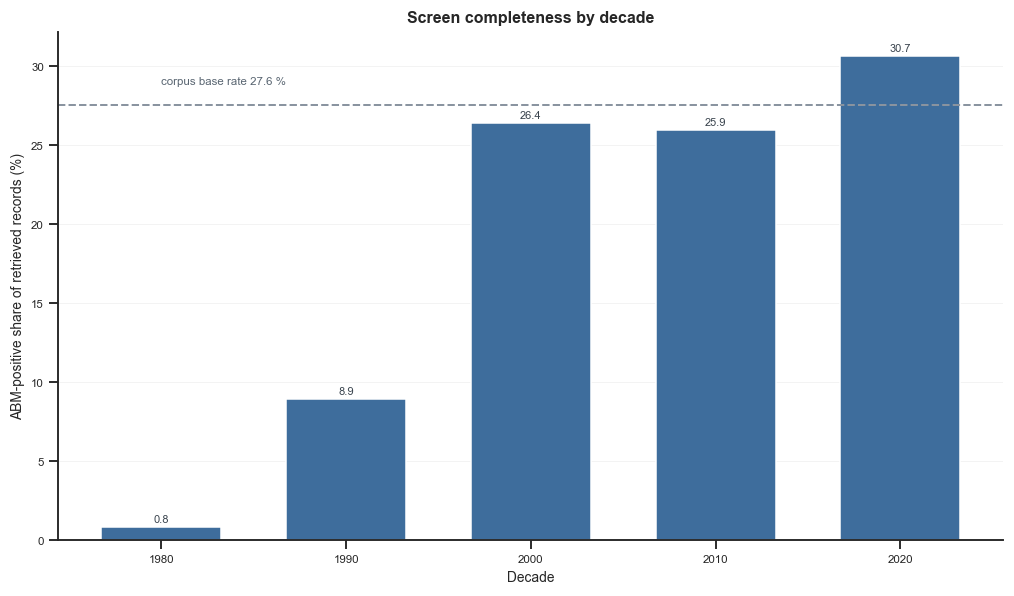

    -> fp08_screen_completeness_a
  [fig 10] fp08_screen_completeness -> 1 panels saved to figures_false_positive/


WindowsPath('D:/Literature-Research-Agent/figures_false_positive/_combined/fp08_screen_completeness.png')

In [17]:
fail = df[df["is_abm"] == -1].copy()
abm_ok = df[df["is_abm"] == 1]
fp_ok = df[df["is_abm"] == 0]

# every record must carry one of the three verdicts; anything else means a stage silently dropped it
_unaccounted = len(df) - len(abm_ok) - len(fp_ok) - len(fail)
print(f"records                 : {len(df):,}")
print(f"  ABM positive          : {len(abm_ok):,}  ({100 * len(abm_ok) / len(df):.2f} %)")
print(f"  false positive        : {len(fp_ok):,}  ({100 * len(fp_ok) / len(df):.2f} %)")
print(f"  model failure         : {len(fail):,}  ({100 * len(fail) / len(df):.2f} %)")
print(f"  unaccounted for       : {_unaccounted:,}")
assert _unaccounted == 0, "some records carry no verdict at all"

print(f"\nverdict present for every record : {bool((df['is_abm'].isin([0, 1])).all())}")
if "llama_stage_status" in df.columns:
    print(f"stage status values             : {df['llama_stage_status'].value_counts().to_dict()}")
if len(fail):
    print(f"failure methodology labels      : {fail['methodology'].value_counts().to_dict()}")
    print(f"failures carrying trigger words : {int(fail['has_kw'].sum()):,}")

# the screen is complete, so the check that matters is whether the ABM share is stable enough to
# trust: it is reported per decade, with the paper counts behind each value
dec = (df.assign(decade=(pd.to_numeric(df["year"], errors="coerce") // 10 * 10))
         .query(f"decade >= 1980 and decade <= {LAST_YEAR // 10 * 10}")
         .groupby("decade")["is_abm"]
         .agg(total="size", abm=lambda s: int((s == 1).sum())))
dec["abm_%"] = (100 * dec["abm"] / dec["total"]).round(2)
print("\nABM share by decade (a completed screen should not jump erratically):")
print(dec.to_string())

fig, ax = plt.subplots(figsize=(9.4, 5.6))
bars = ax.bar(dec.index.astype(int), dec["abm_%"], width=6.5, color=C["abm"], edgecolor="white")
ax.axhline(base_rate, color=C["grey"], ls="--", lw=1.3)
ax.text(1980, base_rate + 1.3, f"corpus base rate {base_rate:.1f} %", fontsize=7.5,
        color="#5A6672")
ax.set_xlabel("Decade", fontsize=9)
ax.set_ylabel("ABM-positive share of retrieved records (%)", fontsize=9)
ax.set_title("Screen completeness by decade", fontsize=10.5, fontweight="bold")
ax.tick_params(labelsize=7.5)
ax.grid(axis="x", visible=False)
ax.set_xticks(dec.index.astype(int))
for b, v in zip(bars, dec["abm_%"]):
    ax.annotate(f"{v:.1f}", xy=(b.get_x() + b.get_width() / 2, v), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=7.2, color="#3A444E")
fig.tight_layout()
save(fig, "fp08_screen_completeness",
     "Every retrieved record carries a verdict, so this figure replaces the earlier model-failure "
     "panel: there are no unparsed stage-1 verdicts left to report. The rising ABM share reflects "
     "the field's growth, not a change in screening strictness.")

## 8. Conclusions

In [18]:
share_2025 = yearly.loc[LAST_YEAR, "fp_share"]
drift_down = drift_tbl[drift_tbl["change_pp"] < 0].sort_values("change_pp")
mas = traj.get("multi-agent system", {})
mas_first = mas[min(mas)]["precision"] if mas else float("nan")
mas_last = mas[max(mas)]["precision"] if mas else float("nan")

# paper-level keyword coverage: only a minority of false positives carry a trigger word at all,
# which is what bounds how much of the false-positive volume a keyword analysis can explain
_fp_papers = int((df["is_abm"] == 0).sum())
_fp_with_kw = int(df.loc[df["is_abm"] == 0, "has_kw"].sum())

print("=" * 96)
print("FALSE-POSITIVE ANALYSIS - HEADLINE NUMBERS")
print("=" * 96)
print(f"retrieval false positives           : {n_fp:,} ({100 * n_fp / len(df):.2f} % of corpus)")
print(f"false-positive share, 1990 -> {LAST_YEAR}  : "
      f"{yearly.loc[1990, 'fp_share']:.1f} % -> {share_2025:.1f} %")
print(f"true:false ratio in {LAST_YEAR}            : "
      f"1 : {yearly.loc[LAST_YEAR, 'fp'] / yearly.loc[LAST_YEAR, 'abm']:.2f}")
print(f"false positives carrying a trigger   : {_fp_with_kw:,} of {_fp_papers:,} "
      f"({100 * _fp_with_kw / _fp_papers:.1f} %) - the keyword figures describe only these")
print(f"\ntop trigger families (BGE, by false positives):")
for _, r in FAM.head(3).iterrows():
    print(f"   {r['family'][:32]:34} {r['fp']:>7,.0f} FPs "
          f"({r['fp_share']:4.1f} % of mapped FP slots), precision {r['precision']:5.1f} %")
print(f"\nfamilies below the {base_rate:.1f} % base rate: "
      f"{int((FAM['precision'] < base_rate).sum())} of {len(FAM)}")
print(f"\n'multi-agent system' precision      : {mas_first:.1f} % -> {mas_last:.1f} %")
print(f"keywords losing ABM meaning         : {len(drift_down)} of {len(drift_tbl)} tracked")
print(f"model failures (separate category)  : {len(fail):,}")
print("\nfigures written:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"   {f.name:<44} {f.stat().st_size / 1024:7.1f} KB")
for f in sorted(FIG_DIR.glob("*.csv")):
    print(f"   {f.name:<44} {f.stat().st_size / 1024:7.1f} KB")

FALSE-POSITIVE ANALYSIS - HEADLINE NUMBERS
retrieval false positives           : 233,788 (72.44 % of corpus)
false-positive share, 1990 -> 2025  : 98.1 % -> 65.3 %
true:false ratio in 2025            : 1 : 1.89
false positives carrying a trigger   : 19,913 of 233,788 (8.5 %) - the keyword figures describe only these

top trigger families (BGE, by false positives):
   swarm intelligence                  13,351 FPs (44.2 % of mapped FP slots), precision  56.0 %
   particle swarm optimisation          7,972 FPs (26.4 % of mapped FP slots), precision  19.6 %
   multi-agent systems                  2,064 FPs ( 6.8 % of mapped FP slots), precision  97.2 %

families below the 27.6 % base rate: 1 of 26

'multi-agent system' precision      : 96.6 % -> 97.2 %
keywords losing ABM meaning         : 5 of 9 tracked
model failures (separate category)  : 0

figures written:
   fp01_fp_trend_a.png                             94.5 KB
   fp01_fp_trend_b.png                            108.2 KB
   fp03_tri

### What the analysis shows

1. **The retrieval query is imprecise but improving.** False positives are **72.4 %** of the corpus
   (233,788 records) against a 27.6 % ABM base rate. In absolute terms they grow **16×** between 1995
   (1,119) and 2025 (17,945), but as a **share** of retrieved records they fall from 98.1 % (1990) to
   **65.3 % (2025)** - a trend with a correlation of -0.77 against year. In 2025 the query returns
   about **1.9 non-ABM papers per ABM paper**, down from 13.7 in 1995. The operational burden is the
   volume, not a deteriorating query.

2. **A few semantic families of trigger words explain most of the misfiring.** Grouping the trigger
   vocabulary with BGE into 26 families shows three families covering **77.4 %** of all mapped
   false-positive keyword slots: `swarm intelligence` (13,337 slots, 44.2 % of them, ABM precision
   56.0 %), `particle swarm optimisation` (7,972, 26.4 %, precision **19.6 %**) and `multi-agent
   systems` (2,064, 6.8 %, precision 97.2 %). The top ten families cover **95.4 %**. Particle-swarm
   language is the one family whose precision sits clearly **below** the 27.6 % corpus base rate:
   papers tagged with it are less likely to be agent-based than a randomly drawn paper from the whole
   retrieval, which is the sharpest way to state how badly it misfires.

   Volume and share rank the families differently, and the share is the more honest measure. Read as
   a **share of the papers using the family**, `particle swarm optimisation` is **80.4 %
   false-positive**, followed by `swarm intelligence` (44.0 %), `optimisation (generic)` (43.1 %) and
   `evolutionary computation` (37.3 %). `multi-agent systems` looks large by volume only because
   73,100 papers use it - just **2.8 %** of them are false positives, and `agent-based modelling`
   sits at **1.1 %**. Six of the 26 families exceed the 18.7 % paper-level false-positive share of
   the whole mapped vocabulary, and every one of them is a swarm, metaheuristic or machine-learning
   family.

3. **Explicit agent-based compounds are near-perfect signals, and their neighbours are not.**
   `agent-based simulation` (99.9 %), `agent-based model` (99.8 %), `individual-based model` (97.5 %)
   and `multi-agent system` (97.3 %) barely misfire, whereas `swarm intelligence` (35.4 %) and
   `particle swarm optimization` (19.1 %) are used by entire literatures that are not doing ABM. The
   distinction is not synonymy - these are not alternative names for one thing - but **surface
   similarity between unrelated concepts**, which is exactly the failure mode a keyword filter cannot
   see.

4. **The composition of the misfiring vocabulary drifts over time.** Family shares of trigger-related
   false positives shift substantially between 1990 and 2025, and the abstract-level evidence
   confirms the direction independently: among *all* false-positive abstracts the
   computing/optimisation theme rises from **7.5 % in the 1990s to 39.3 % in 2020-2024**, while
   chemistry/materials stays flat (12.7 % -> 12.8 %) and health rises only modestly (16.0 % -> 24.0 %).
   The share of abstracts mentioning `optimization` rises from 0.8 % to 23.8 % and `swarm` from 5.4 %
   to 23.7 %, while `agent` is essentially flat (2.1 % -> 2.3 %) and `multi-agent` stays near 1 %.
   The corpus is being pulled toward machine-learning and metaheuristic work that shares surface
   vocabulary with agent-based modelling. Because this evidence uses only the abstracts - not stage
   1's keyword extraction - it cannot be an artefact of the prompt that produced the trigger keywords.

5. **The keyword extractor under-reports on false positives, and that bounds what any keyword
   analysis can claim.** 91.5 % of false positives carry no trigger keyword at all, so the
   keyword-level figures describe only 19,913 of 233,788 papers. They are the right tool for asking
   *which words misfire*, and the wrong tool for asking *how much* misfires. This is why the notebook
   closes with the abstract-level check rather than relying on the keyword tables alone.

6. **The screen is now complete.** The refreshed corpus contains **zero** `is_abm = -1` records,
   against 4,118 before. Every retrieved record carries a verdict, so no count in this notebook is
   diluted by silently dropped records. An incomplete screen would have been the one error mode
   capable of biasing every number here without leaving a visible trace.

7. **Practical consequence for anyone reusing this corpus.** The `is_abm = 1` subset is trustworthy;
   the raw retrieval query is not. If ABM papers are needed, use the labelled subset rather than the
   query, and any future keyword-only filter should drop the particle-swarm and generic-optimisation
   families, which contribute the large majority of the misfiring vocabulary at low precision.